# **Final Project: Machine Learning**

---

| | |
|---|---|
| **University** | Tecnun - Universidad de Navarra|
| **Course** | Machine Learning |
| **Dataset** | Breast Cancer Wisconsin (Diagnostic) |
| **Year** | 2025/2026 |
| **Created by** | Kinga Kerekes |

---

## **1. Introduction**

Breast cancer is one of the most prevalent malignancies worldwide, representing both a significant clinical and public-health challenge. Early detection is critical: the WHO reports that in high-income countries, age-standardized breast cancer mortality dropped by 40% between the 1980s and 2020, largely due to improvements in early diagnosis and treatment. This progress highlights how critical early detection is.

## **2. Problem Formulation**


**The dataset:**
The Wisconsin Breast Cancer (Diagnostic) dataset contains **569 samples**, each described by **30 continuous numerical features** derived from FNA cell-nucleus images, and a binary target label: **Malignant (M = 1)** or **Benign (B = 0)**.

**Unsupervised question:**
*Is there hidden structure in the 30-dimensional feature space?* We use PCA, t-SNE, and clustering algorithms to discover natural groupings in the data, evaluated using the silhouette score — a purely internal, label-free metric. As an outlook, we will later verify whether the discovered structure corresponds to the true diagnosis.

**Supervised question:**
*Can we reliably predict whether a tumour is malignant or benign from the 30 nucleus measurements?* Clinical success requires high recall for malignant cases — a missed cancer (false negative) is far more dangerous than an unnecessary follow-up (false positive).

**Success criteria measurements:**
- *Unsupervised*: Silhouette score
- *Supervised*: Recall and F1-score



## **Importing the Necessary Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import mode


from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
)


import math
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [ ]:
plt.style.use('seaborn-v0_8-dark')

C_BENIGN    = '#4D869B'
C_MALIGNANT = '#333A57'
COLORS      = [C_BENIGN, C_MALIGNANT]

cm_cmap = LinearSegmentedColormap.from_list('cm_cmap', ['#FFFFFF', '#336063'])

LABEL_NAMES = ['Benign (0)', 'Malignant (1)']


## **3. Data Understanding & EDA**

### 3.1 Dataset Overview

In [ ]:
raw = load_breast_cancer(as_frame=True)
X   = raw.data
y   = raw.target

y = 1 - y

print('Dataset shape (X):', X.shape)
print('Target shape  (y):', y.shape)
print('Feature names:', list(X.columns))
print('\nClass mapping: 0 = Benign, 1 = Malignant')

Dataset shape (X): (569, 30)
Target shape  (y): (569,)
Feature names: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Class mapping: 0 = Benign, 1 = Malignant


In [ ]:
display(X.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
print('\nInfo:')
X.info()
print('\nMissing values per feature:')
print(X.isnull().sum().sum(), 'total missing values (expected: 0)')


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error   

In [ ]:
print('Summary statistics (all 30 features):')
display(X.describe().T.round(4))

Summary statistics (all 30 features):


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100
mean texture,569.0,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800
mean perimeter,569.0,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000
mean area,569.0,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000
mean smoothness,569.0,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634
mean compactness,569.0,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454
mean concavity,569.0,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268
mean concave points,569.0,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012
mean symmetry,569.0,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040
mean fractal dimension,569.0,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974


### 3.2 Class Distribution

Class distribution (proportions):
  Benign    (0): 62.7%
  Malignant (1): 37.3%


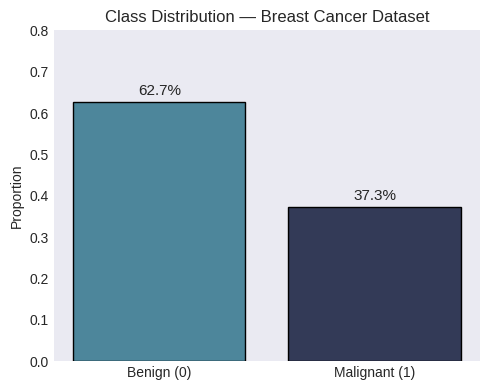

In [ ]:
counts = y.value_counts(normalize=True)
print('Class distribution (proportions):')
print(f'  Benign    (0): {counts[0]:.1%}')
print(f'  Malignant (1): {counts[1]:.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Benign (0)', 'Malignant (1)'],
              [counts[0], counts[1]],
              color=COLORS, edgecolor='black')
for bar, val in zip(bars, [counts[0], counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Proportion')
ax.set_title('Class Distribution — Breast Cancer Dataset')
ax.set_ylim(0, 0.8)
plt.tight_layout()
plt.show()

### 3.3 Feature Distributions by Class

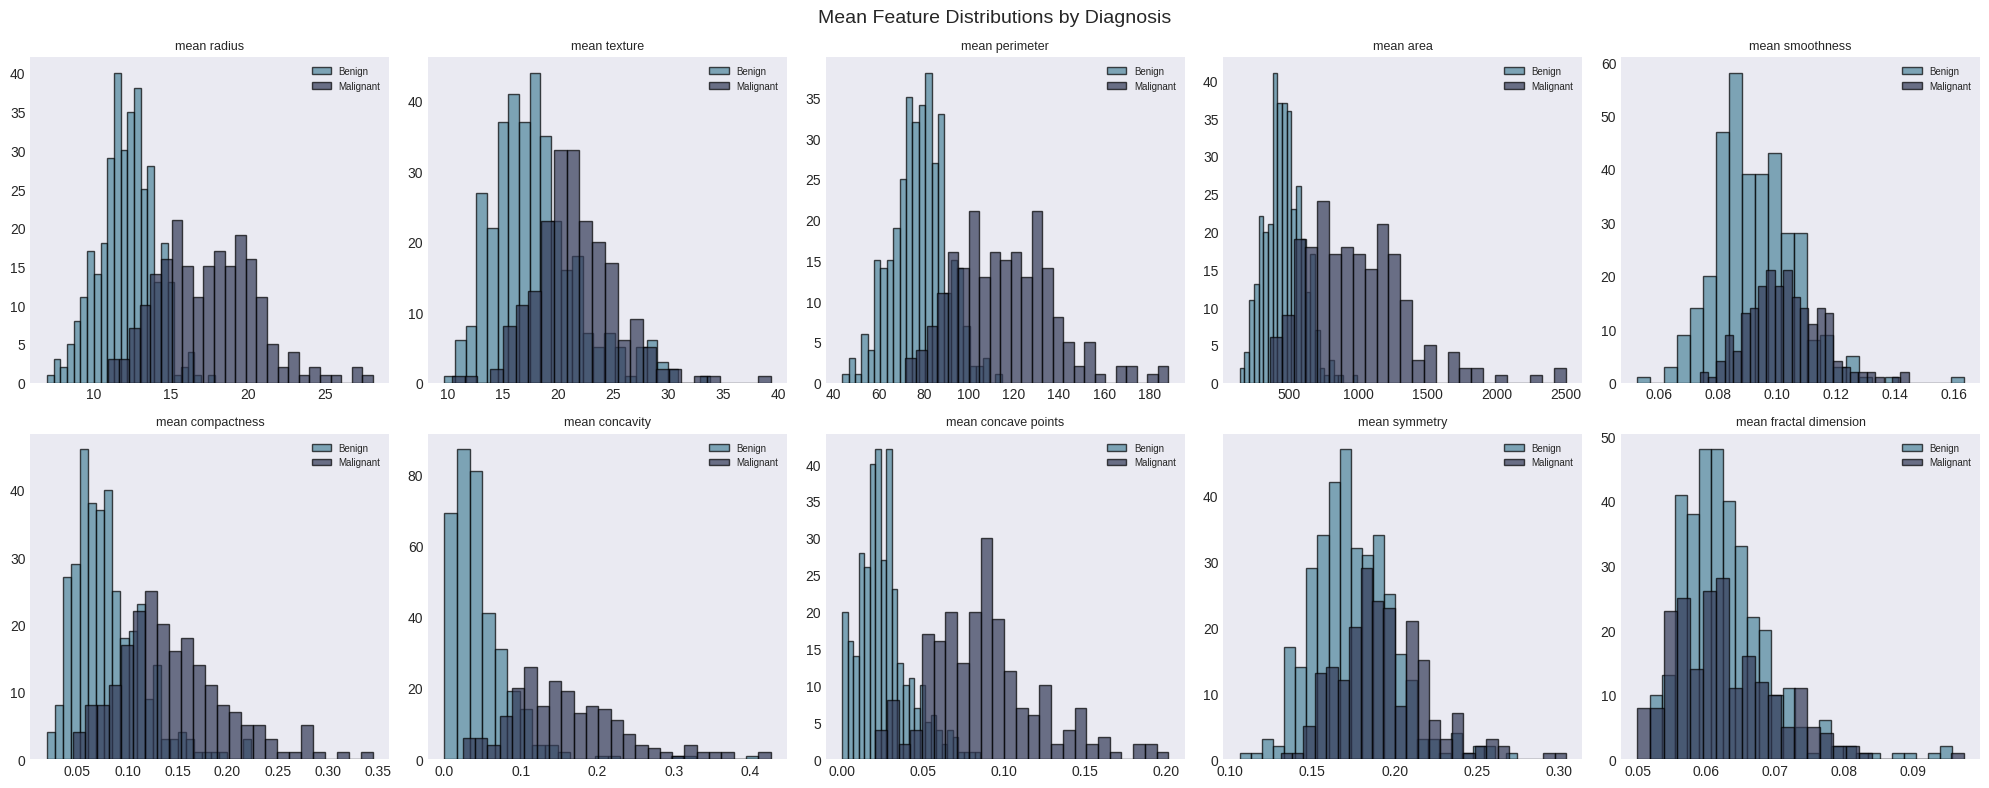

In [ ]:
mean_features = [c for c in X.columns if 'mean' in c]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    axes[i].hist(X[col][y == 0], alpha=0.7, label='Benign',    color=C_BENIGN,    bins=25, edgecolor='black')
    axes[i].hist(X[col][y == 1], alpha=0.7, label='Malignant', color=C_MALIGNANT, bins=25, edgecolor='black')
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Mean Feature Distributions by Diagnosis', fontsize=14)
plt.tight_layout()
plt.show()

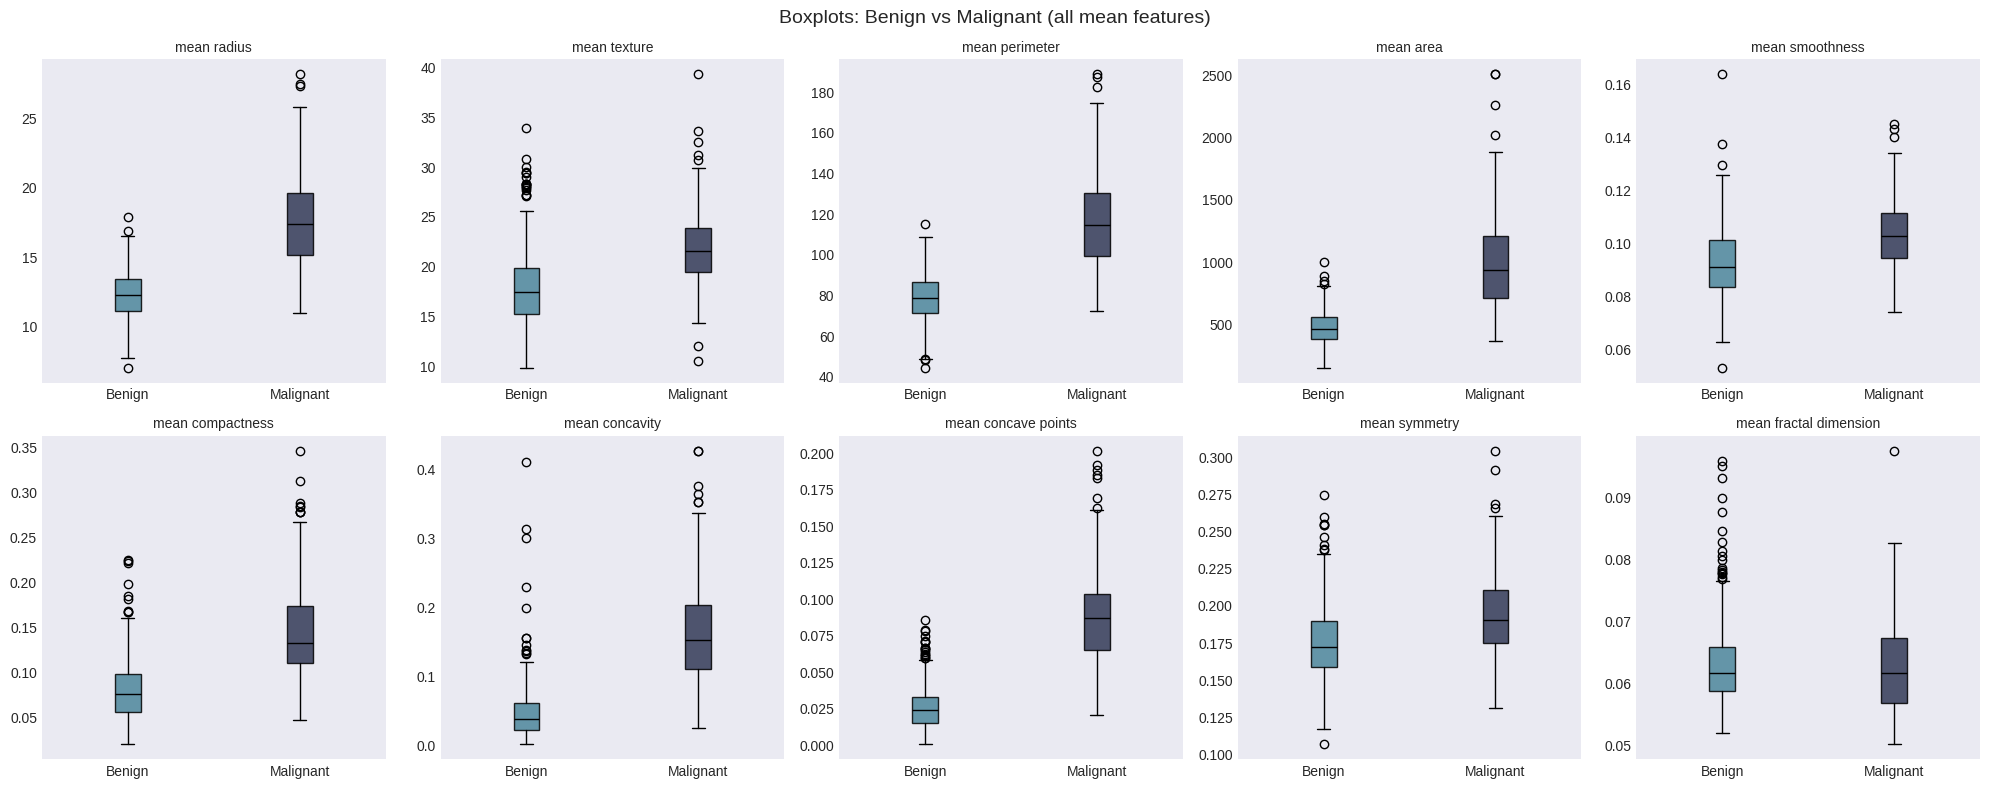

In [ ]:
mean_features = [c for c in X.columns if 'mean' in c]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, mean_features):
    data_b = X[col][y == 0]
    data_m = X[col][y == 1]
    bp = ax.boxplot([data_b, data_m], labels=['Benign', 'Malignant'], patch_artist=True)
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        patch.set_edgecolor('black')
    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(bp[element], color='black')
    plt.setp(bp['fliers'], markeredgecolor='black')
    ax.set_title(col, fontsize=10)

plt.suptitle('Boxplots: Benign vs Malignant (all mean features)', fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 Correlation Analysis

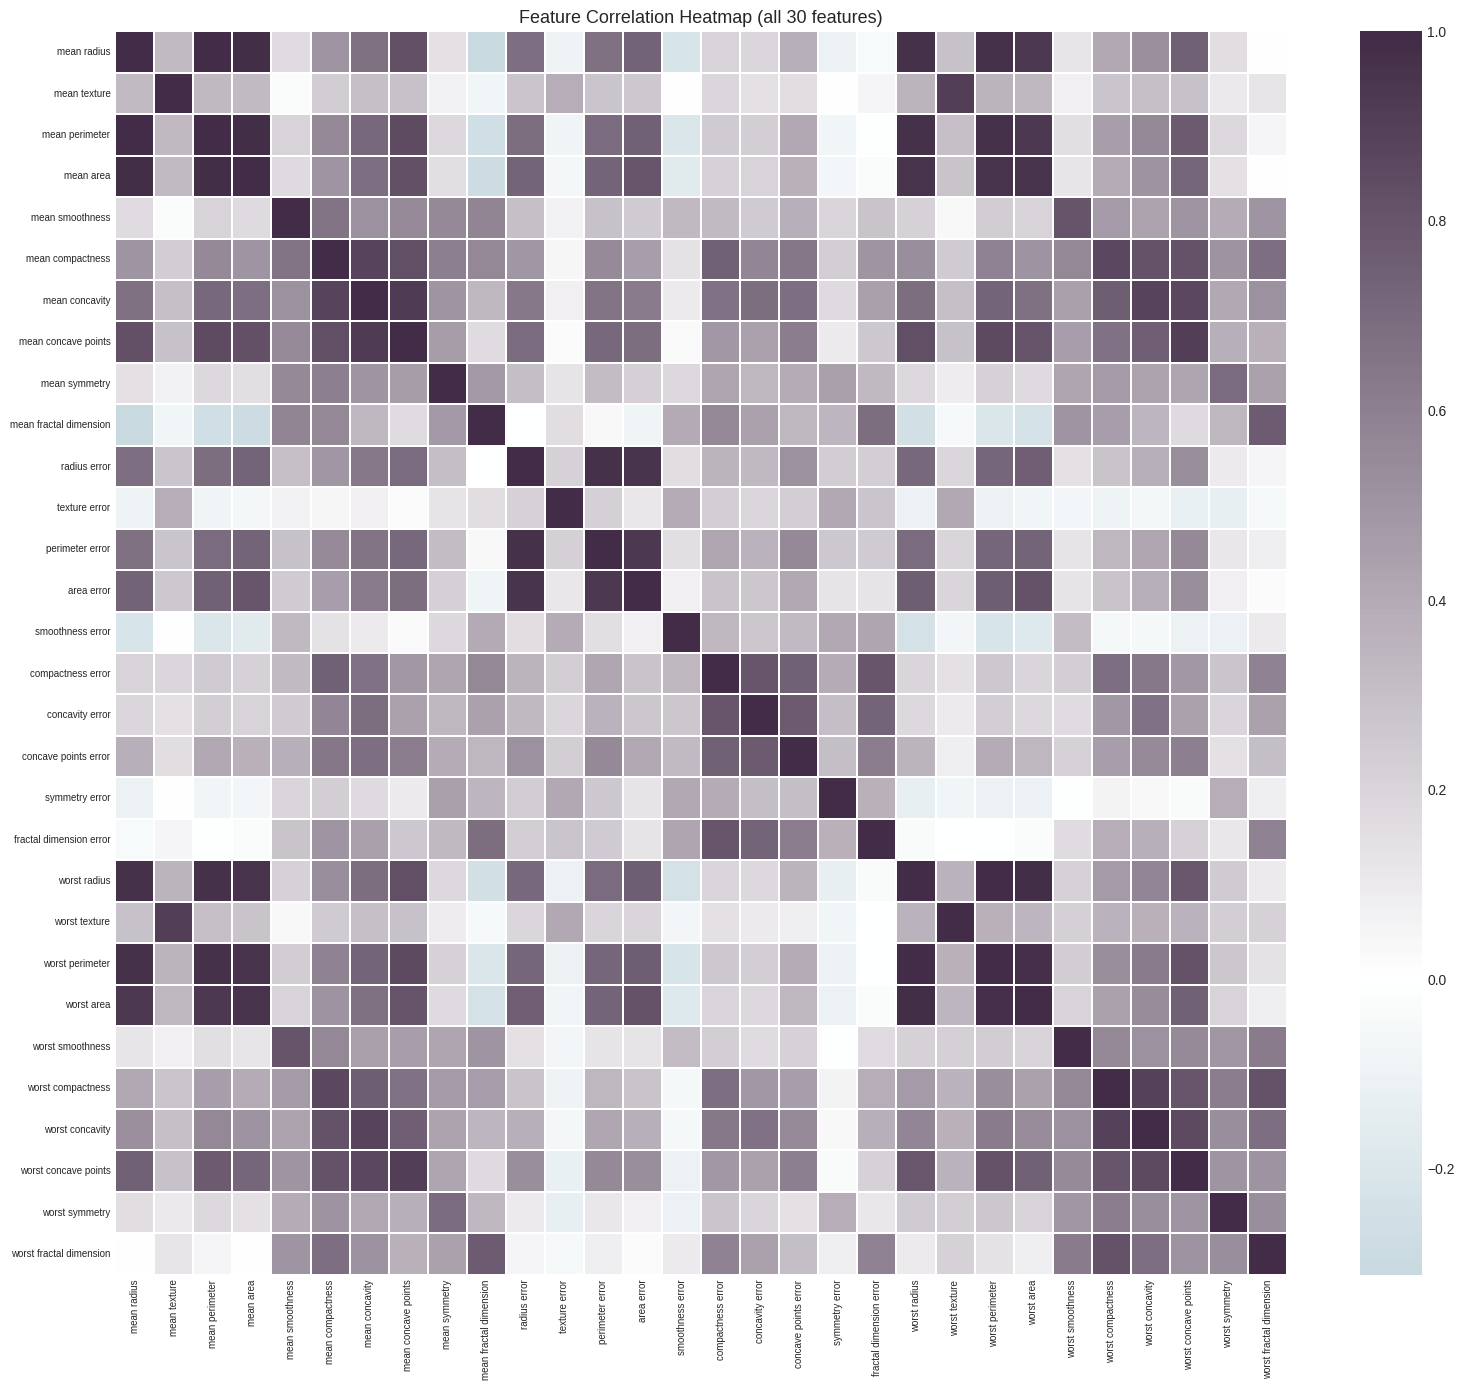

Observation: the mean/SE/worst triplicates for each nucleus measurement
are highly correlated (r > 0.9 for radius, perimeter, area).
→ There is substantial redundancy — PCA should compress this well.


In [ ]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, ax=ax, cmap=LinearSegmentedColormap.from_list('custom_div', ['#4D869B', '#FFFFFF', '#422C47']), center=0,
            linewidths=0.3, annot=False,
            xticklabels=X.columns, yticklabels=X.columns)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
ax.set_title('Feature Correlation Heatmap (all 30 features)', fontsize=13)
plt.tight_layout()
plt.show()

print('Observation: the mean/SE/worst triplicates for each nucleus measurement')
print('are highly correlated (r > 0.9 for radius, perimeter, area).')
print('→ There is substantial redundancy — PCA should compress this well.')

## **4. Preprocessing**




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]} samples')
print(f'Test set:      {X_test.shape[0]} samples')
print(f'\nTraining class distribution:')
print(y_train.value_counts(normalize=True).rename({0:'Benign', 1:'Malignant'}))
print(f'\nTest class distribution:')
print(y_test.value_counts(normalize=True).rename({0:'Benign', 1:'Malignant'}))

Training set:  455 samples
Test set:      114 samples

Training class distribution:
target
Benign       0.626374
Malignant    0.373626
Name: proportion, dtype: float64

Test class distribution:
target
Benign       0.631579
Malignant    0.368421
Name: proportion, dtype: float64


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler fitted on training data only.')
print('X_train_scaled and X_test_scaled are ready for all downstream models.')


StandardScaler fitted on training data only.
X_train_scaled and X_test_scaled are ready for all downstream models.


In [ ]:
def align_clusters(cluster_labels, true_labels):
    mapping = {}
    for c in np.unique(cluster_labels):
        true_in_c = true_labels[cluster_labels == c]
        mapping[c] = mode(true_in_c, keepdims=True).mode[0]
    return np.array([mapping[c] for c in cluster_labels])

print('Helper function defined: align_clusters (used in outlook section only)')


Helper function defined: align_clusters (used in outlook section only)


## **5. Unsupervised Learning**




### 5.1 PCA — Principal Component Analysis

In [ ]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_90 = np.searchsorted(cumulative, 0.90) + 1
n_95 = np.searchsorted(cumulative, 0.95) + 1
print(f'Components needed for 90% variance: {n_90}')
print(f'Components needed for 95% variance: {n_95}')

Components needed for 90% variance: 7
Components needed for 95% variance: 10


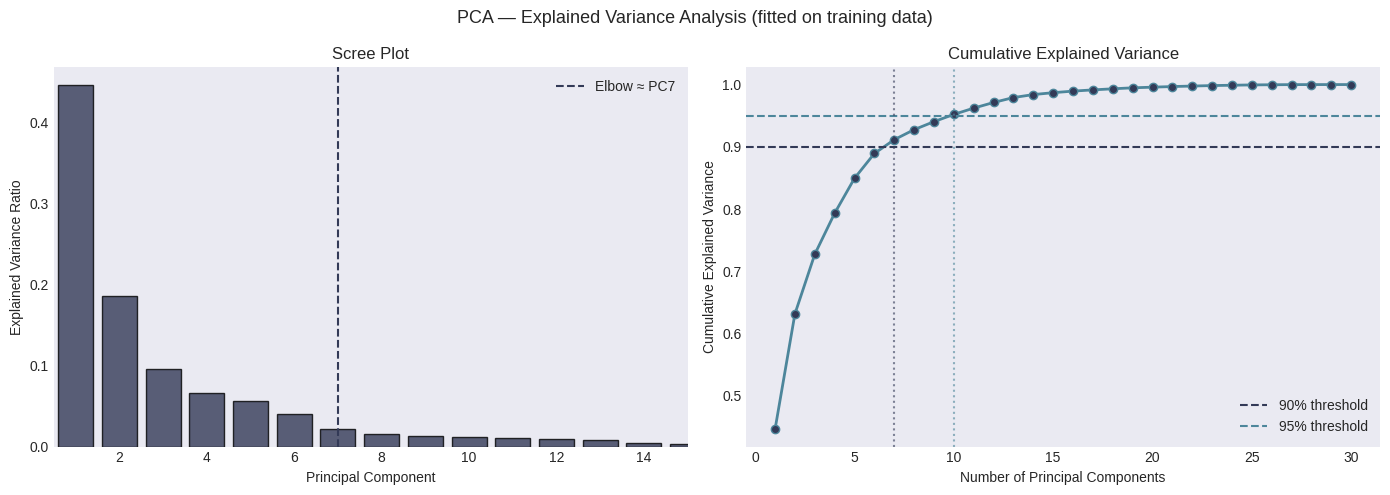

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained)+1), explained, color=C_MALIGNANT, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xlim(0.5, 15)
axes[0].axvline(n_90, color=C_MALIGNANT, linestyle='--', label=f'Elbow ≈ PC{n_90}')
axes[0].legend()

axes[1].plot(range(1, len(cumulative)+1), cumulative, marker='o',
             color=C_BENIGN, markerfacecolor=C_MALIGNANT, linewidth=2)
axes[1].axhline(0.90, color=C_MALIGNANT,    linestyle='--', label='90% threshold')
axes[1].axhline(0.95, color=C_BENIGN, linestyle='--', label='95% threshold')
axes[1].axvline(n_90, color=C_MALIGNANT,    linestyle=':',  alpha=0.6)
axes[1].axvline(n_95, color=C_BENIGN, linestyle=':',  alpha=0.6)
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.suptitle('PCA — Explained Variance Analysis (fitted on training data)', fontsize=13)
plt.tight_layout()
plt.show()

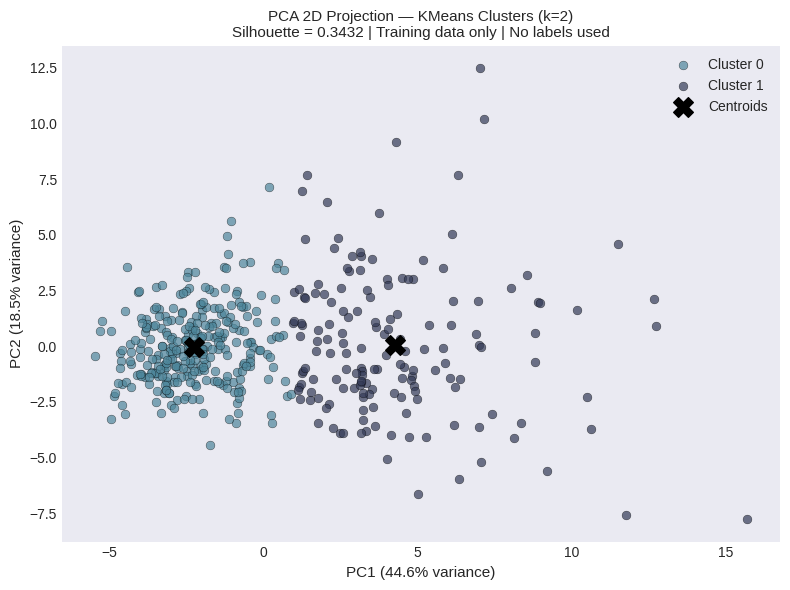

In [ ]:
pca_2d = PCA(n_components=2)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)
km_train        = KMeans(n_clusters=2, random_state=42, n_init=10)
km_train_labels = km_train.fit_predict(X_train_scaled)
sil_km_vis      = silhouette_score(X_train_scaled, km_train_labels)
centroids_pca_vis = pca_2d.transform(km_train.cluster_centers_)

fig, ax = plt.subplots(figsize=(8, 6))
for clust, color in zip([0, 1], COLORS):
    mask = km_train_labels == clust
    ax.scatter(X_train_pca2[mask, 0], X_train_pca2[mask, 1],
               label=f'Cluster {clust}', color=color, alpha=0.7,
               edgecolors='black', linewidths=0.3, s=40)
ax.scatter(centroids_pca_vis[:, 0], centroids_pca_vis[:, 1],
           marker='X', s=200, c='black', zorder=5, label='Centroids')
ax.set_xlabel(f'PC1 ({explained[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({explained[1]:.1%} variance)', fontsize=11)
ax.set_title(f'PCA 2D Projection — KMeans Clusters (k=2)\n'
             f'Silhouette = {sil_km_vis:.4f} | Training data only | No labels used',
             fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


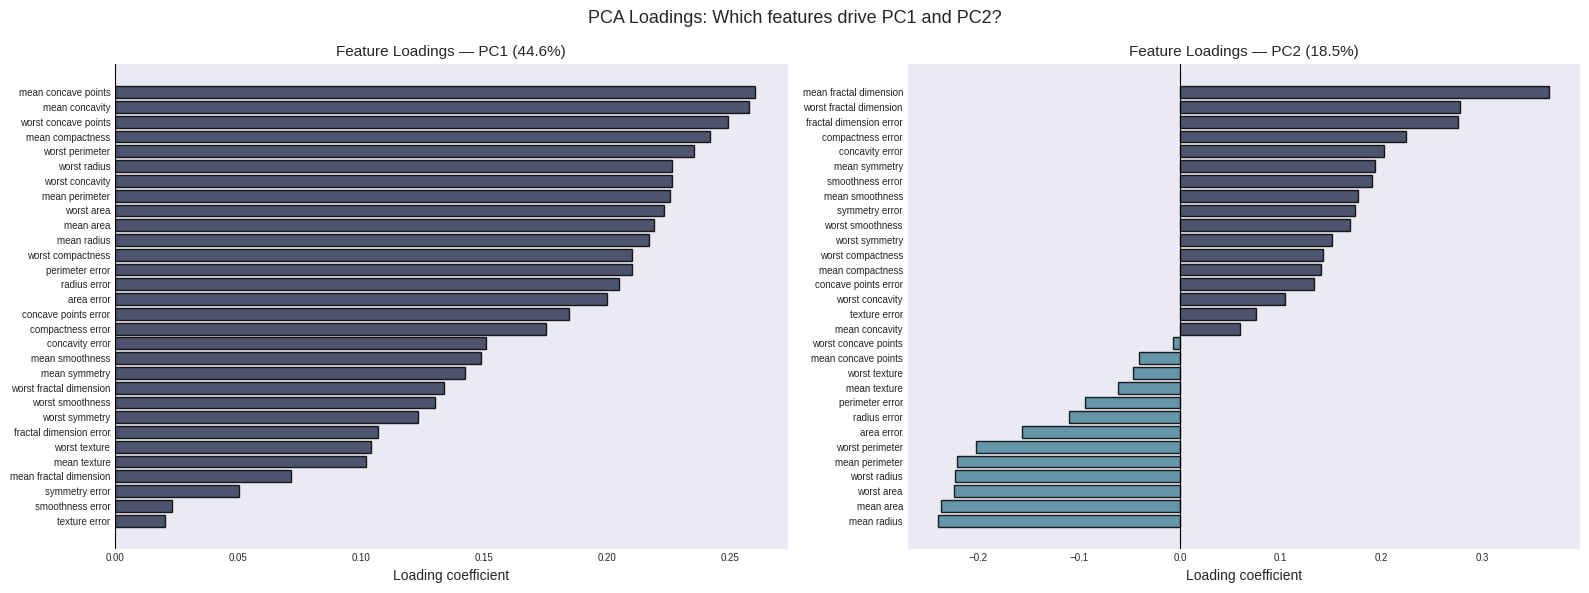

In [ ]:

loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=X.columns,
    columns=['PC1', 'PC2']
)

explained_var_pc1 = pca_full.explained_variance_ratio_[0]
explained_var_pc2 = pca_full.explained_variance_ratio_[1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (ax, pc) in enumerate(zip(axes, ['PC1', 'PC2'])):
    sorted_load = loadings[pc].sort_values()
    colors_bar = [C_MALIGNANT if v > 0 else C_BENIGN for v in sorted_load]
    ax.barh(sorted_load.index, sorted_load.values, color=colors_bar, edgecolor='black', alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    if i == 0:
        ax.set_title(f'Feature Loadings — PC1 ({explained_var_pc1:.1%})', fontsize=11)
    else:
        ax.set_title(f'Feature Loadings — PC2 ({explained_var_pc2:.1%})', fontsize=11)
    ax.set_xlabel('Loading coefficient')
    ax.tick_params(labelsize=7)

plt.suptitle('PCA Loadings: Which features drive PC1 and PC2?', fontsize=13)
plt.tight_layout()
plt.show()

### 5.2 t-SNE Visualisation


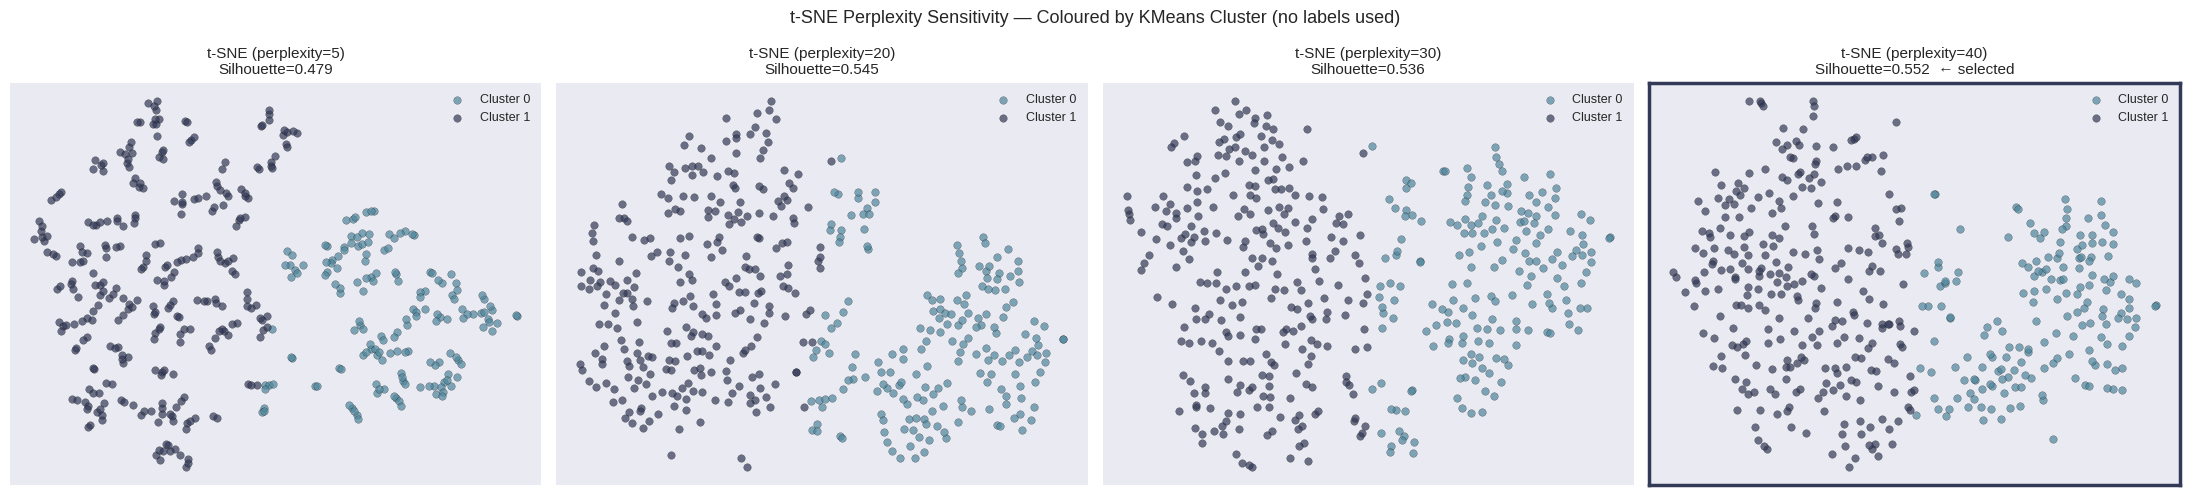

Best perplexity by silhouette: 40 (score=0.552)
Perplexity=40 is selected for the main t-SNE analysis below.


In [ ]:
perplexities = [5, 20, 30, 40]
best_perp = None
best_sil  = -1
tsne_embeddings = {}

for perp in perplexities:
    tsne = TSNE(n_components=2, perplexity=perp, max_iter=1000,
                random_state=42, init='pca', learning_rate='auto')
    X_tsne = tsne.fit_transform(X_train_scaled)
    km_perp = KMeans(n_clusters=2, random_state=42, n_init=10)
    clust_perp = km_perp.fit_predict(X_tsne)
    sil_perp = silhouette_score(X_tsne, clust_perp)
    tsne_embeddings[perp] = (X_tsne, clust_perp, sil_perp)
    if sil_perp > best_sil:
        best_sil  = sil_perp
        best_perp = perp

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, perp in zip(axes, perplexities):
    X_tsne, clust_perp, sil_perp = tsne_embeddings[perp]
    for clust, color in zip([0, 1], COLORS):
        mask = clust_perp == clust
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   label=f'Cluster {clust}', color=color, alpha=0.7,
                   edgecolors='black', linewidths=0.2, s=30)
    title = f't-SNE (perplexity={perp})\nSilhouette={sil_perp:.3f}'
    if perp == best_perp:
        title += '  ← selected'
        for spine in ax.spines.values():
            spine.set_edgecolor(C_MALIGNANT)
            spine.set_linewidth(2.5)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('t-SNE Perplexity Sensitivity — Coloured by KMeans Cluster (no labels used)',
             fontsize=13)
plt.tight_layout()
plt.show()

print(f'Best perplexity by silhouette: {best_perp} (score={best_sil:.3f})')
print(f'Perplexity={best_perp} is selected for the main t-SNE analysis below.')


In [ ]:
tsne_best = TSNE(n_components=2, perplexity=best_perp, max_iter=1000,
                 random_state=42, init='pca', learning_rate='auto')
X_train_tsne_best = tsne_best.fit_transform(X_train_scaled)
print(f't-SNE 2D projection computed (perplexity={best_perp}, init=pca) — used throughout clustering section.')

t-SNE 2D projection computed (perplexity=40, init=pca) — used throughout clustering section.


### 5.3 Clustering

#### 5.3.1 K-Means

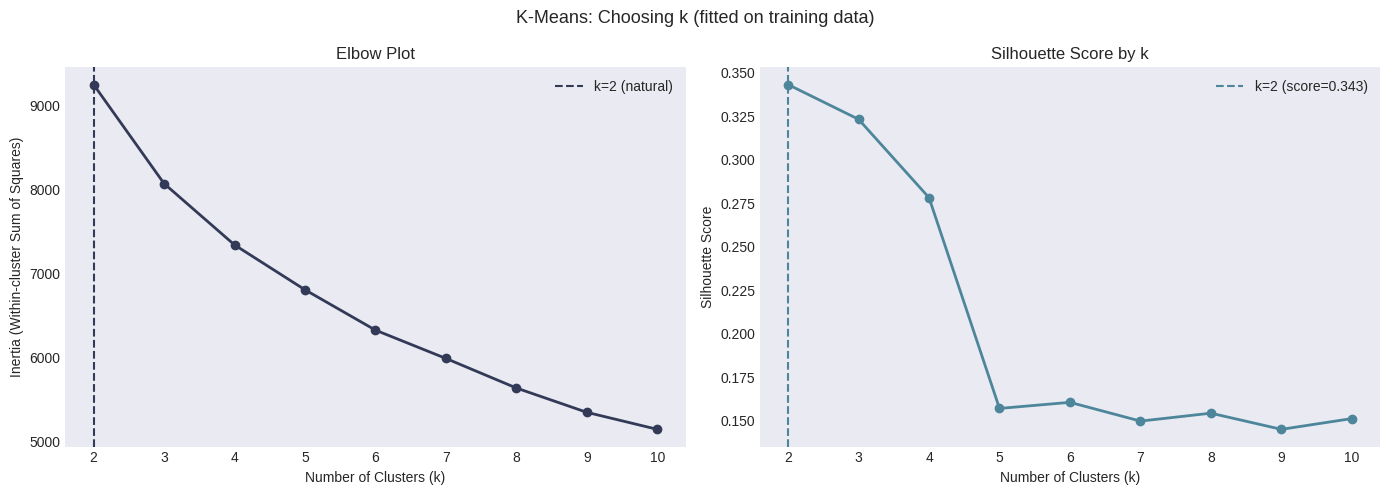

Highest silhouette score at k=2: 0.3432
Both elbow and silhouette confirm k=2 as the natural partition.


In [ ]:
k_range     = range(2, 11)
inertias    = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', color=C_MALIGNANT, linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].set_title('Elbow Plot')
axes[0].axvline(2, color=C_MALIGNANT, linestyle='--', label='k=2 (natural)')
axes[0].legend()

axes[1].plot(k_range, silhouettes, marker='o', color=C_BENIGN, linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
axes[1].axvline(2, color=C_BENIGN, linestyle='--', label=f'k=2 (score={silhouettes[0]:.3f})')
axes[1].legend()

plt.suptitle('K-Means: Choosing k (fitted on training data)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Highest silhouette score at k=2: {silhouettes[0]:.4f}')
print('Both elbow and silhouette confirm k=2 as the natural partition.')

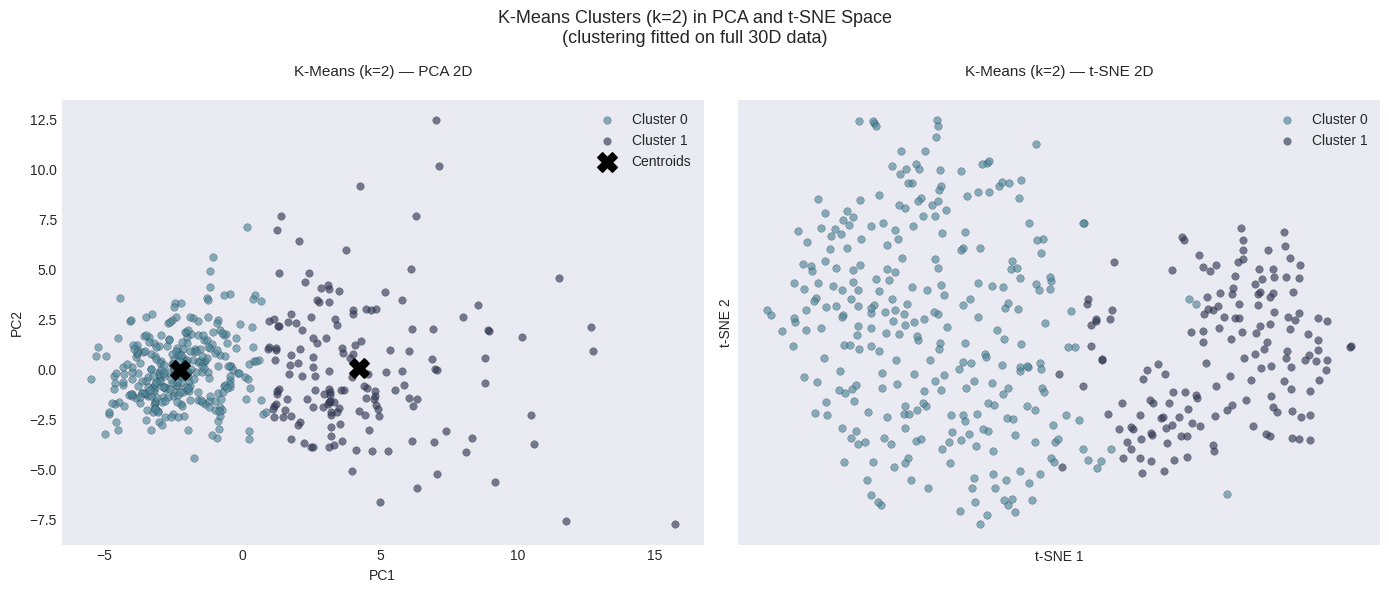

In [ ]:
centroids_pca = pca_2d.transform(km_train.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for clust, color in zip([0, 1], COLORS):
    mask = km_train_labels == clust
    axes[0].scatter(X_train_pca2[mask, 0], X_train_pca2[mask, 1],
                    label=f'Cluster {clust}', color=color, alpha=0.65,
                    edgecolors='black', linewidths=0.2, s=30)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker='X', s=200, c='black', zorder=5, label='Centroids')
axes[0].set_title(f'K-Means (k=2) — PCA 2D\n', fontsize=11)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

for clust, color in zip([0, 1], COLORS):
    mask = km_train_labels == clust
    axes[1].scatter(X_train_tsne_best[mask, 0], X_train_tsne_best[mask, 1],
                    label=f'Cluster {clust}', color=color, alpha=0.65,
                    edgecolors='black', linewidths=0.2, s=30)
axes[1].set_title(f'K-Means (k=2) — t-SNE 2D\n', fontsize=11)
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].set_xticks([]); axes[1].set_yticks([])
axes[1].legend()

plt.suptitle('K-Means Clusters (k=2) in PCA and t-SNE Space\n(clustering fitted on full 30D data)', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
km_rows       = []
km_labels_dict = {}

for rep_name, X_rep in [('Baseline (30D)', X_train_scaled),
                         ('PCA 2D',         X_train_pca2),
                         ('t-SNE 2D',       X_train_tsne_best)]:
    if rep_name == 'Baseline (30D)':
        hard_labels = km_train_labels
        sil = sil_km_vis
    else:
        km = KMeans(n_clusters=2, random_state=42, n_init=10)
        hard_labels = km.fit_predict(X_rep)
        sil = silhouette_score(X_rep, hard_labels)

    km_rows.append({
        'Representation': rep_name,
        'Silhouette':   round(sil, 4),
    })
    km_labels_dict[rep_name] = hard_labels

km_df = pd.DataFrame(km_rows).set_index('Representation')
print('K-Means (k=2) — Silhouette Scores (internal, label-free):')
display(km_df)

km_labels_train = km_labels_dict['Baseline (30D)']
sil_km          = km_df.loc['Baseline (30D)', 'Silhouette']


K-Means (k=2) — Silhouette Scores (internal, label-free):


,Silhouette
Representation,
Baseline (30D),0.3432
PCA 2D,0.5092
t-SNE 2D,0.5521


#### 5.3.2 Gaussian Mixture Models (GMM)

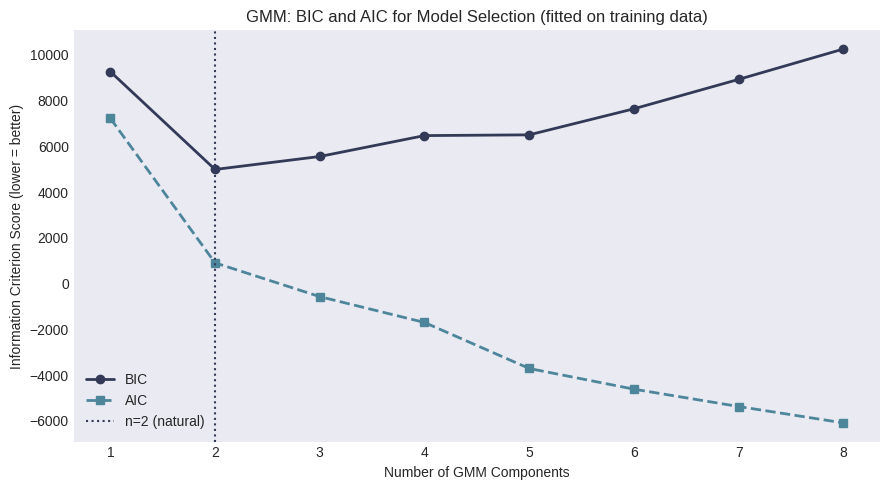

In [ ]:
n_components_range = range(1, 9)
bic_scores = []
aic_scores = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full',
                          random_state=42, max_iter=200)
    gmm.fit(X_train_scaled)
    bic_scores.append(gmm.bic(X_train_scaled))
    aic_scores.append(gmm.aic(X_train_scaled))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_components_range, bic_scores, marker='o', label='BIC',
        color=C_MALIGNANT, linewidth=2)
ax.plot(n_components_range, aic_scores, marker='s', label='AIC',
        color=C_BENIGN, linewidth=2, linestyle='--')
ax.axvline(2, color=C_MALIGNANT, linestyle=':', label='n=2 (natural)')
ax.set_xlabel('Number of GMM Components')
ax.set_ylabel('Information Criterion Score (lower = better)')
ax.set_title('GMM: BIC and AIC for Model Selection (fitted on training data)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

best_n = n_components_range[bic_scores.index(min(bic_scores))]


In [ ]:
gmm_representations = {
    'Baseline (30D)': X_train_scaled,
    'PCA 2D':         X_train_pca2,
    't-SNE 2D':       X_train_tsne_best,
}

gmm_rows = []
gmm_labels_dict = {}
gmm_proba_dict  = {}

for rep_name, X_rep in gmm_representations.items():
    gmm = GaussianMixture(n_components=2, covariance_type='full',
                          random_state=42, max_iter=200)
    gmm.fit(X_rep)
    hard_labels = gmm.predict(X_rep)
    soft_proba  = gmm.predict_proba(X_rep)

    sil = silhouette_score(X_rep, hard_labels)

    gmm_rows.append({
        'Representation': rep_name,
        'Silhouette':   round(sil, 4),
    })
    gmm_labels_dict[rep_name] = hard_labels
    gmm_proba_dict[rep_name]  = soft_proba

gmm_df = pd.DataFrame(gmm_rows).set_index('Representation')
print('GMM (n=2, full covariance) — Silhouette Scores (internal, label-free):')
display(gmm_df)

GMM (n=2, full covariance) — Silhouette Scores (internal, label-free):


,Silhouette
Representation,
Baseline (30D),0.3142
PCA 2D,0.4736
t-SNE 2D,0.5532


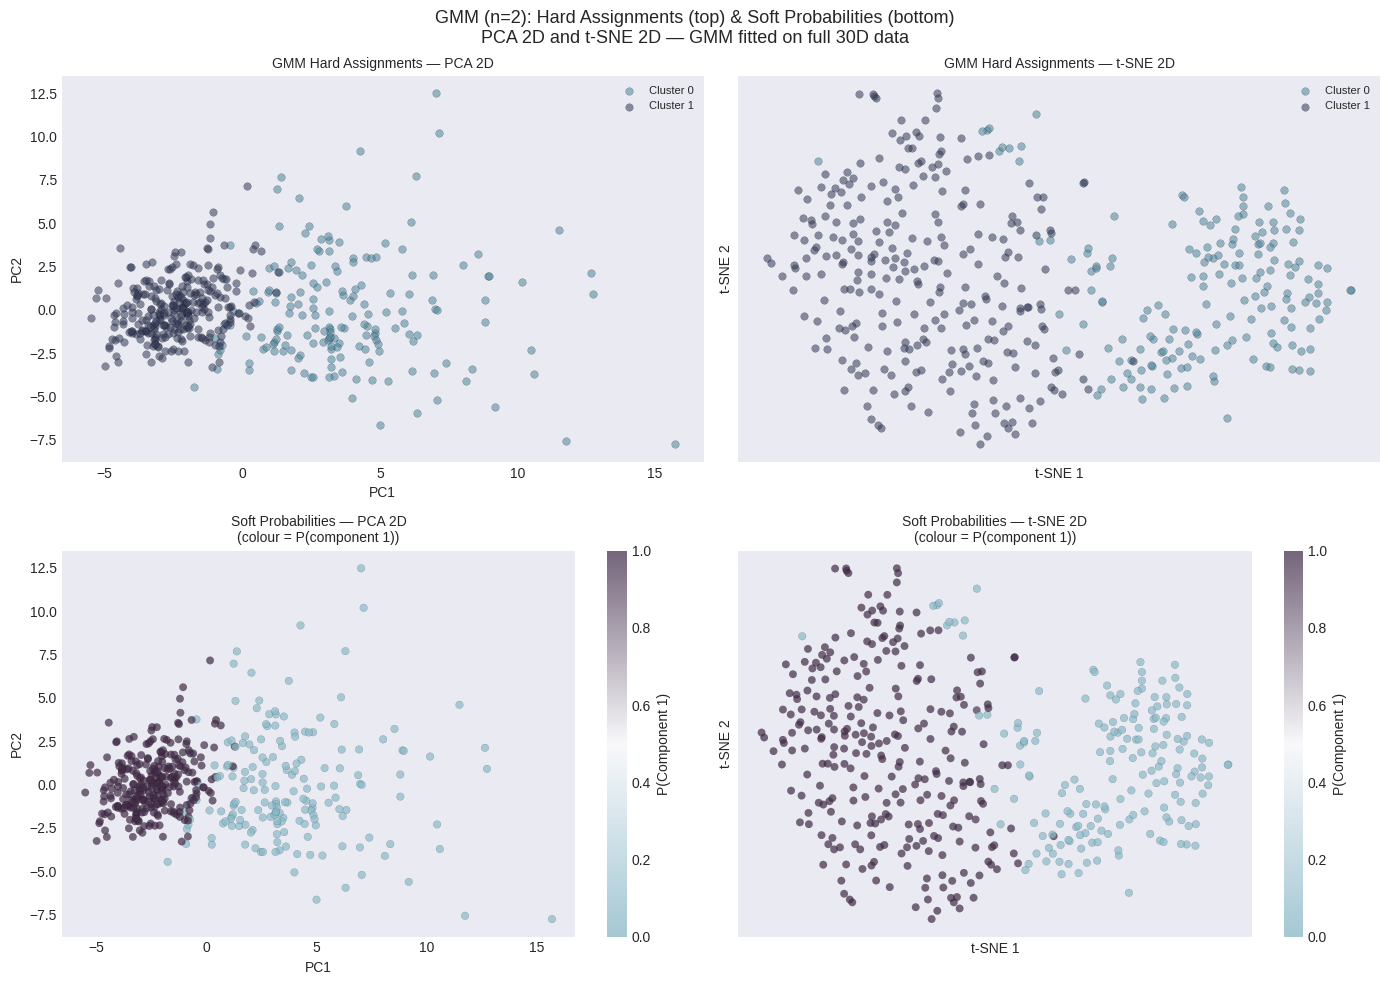

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

representations = [
    ('PCA 2D',   X_train_pca2,      'PC1',    'PC2'),
    ('t-SNE 2D', X_train_tsne_best, 't-SNE 1','t-SNE 2'),
]

soft        = gmm_proba_dict['Baseline (30D)']
hard_labels = soft.argmax(axis=1)
sil_val     = gmm_df.loc['Baseline (30D)', 'Silhouette']
proba_comp1 = soft[:, 1]

for col, (rep_name, X_proj, xlabel, ylabel) in enumerate(representations):

    ax_top = axes[0, col]
    for clust, color in zip([0, 1], COLORS):
        mask = hard_labels == clust
        ax_top.scatter(X_proj[mask, 0], X_proj[mask, 1],
                       color=color, alpha=0.55, edgecolors='black',
                       linewidths=0.2, s=30, label=f'Cluster {clust}')
    ax_top.set_title(f'GMM Hard Assignments — {rep_name}', fontsize=10)
    ax_top.set_xlabel(xlabel); ax_top.set_ylabel(ylabel)
    ax_top.legend(fontsize=8)
    if rep_name == 't-SNE 2D':
        ax_top.set_xticks([]); ax_top.set_yticks([])

    ax_bot = axes[1, col]
    sc = ax_bot.scatter(X_proj[:, 0], X_proj[:, 1],
                        c=proba_comp1,
                        cmap=LinearSegmentedColormap.from_list(
                            'custom_div_r', ['#88BAC8', '#FFFFFF', '#422C47']),
                        alpha=0.7, edgecolors='black', linewidths=0.1, s=30)
    plt.colorbar(sc, ax=ax_bot, label='P(Component 1)')
    ax_bot.set_title(f'Soft Probabilities — {rep_name}\n(colour = P(component 1))', fontsize=10)
    ax_bot.set_xlabel(xlabel); ax_bot.set_ylabel(ylabel)
    if rep_name == 't-SNE 2D':
        ax_bot.set_xticks([]); ax_bot.set_yticks([])

plt.suptitle('GMM (n=2): Hard Assignments (top) & Soft Probabilities (bottom)\n'
             'PCA 2D and t-SNE 2D — GMM fitted on full 30D data', fontsize=13)
plt.tight_layout()
plt.show()

#### 5.3.3 Hierarchical Clustering

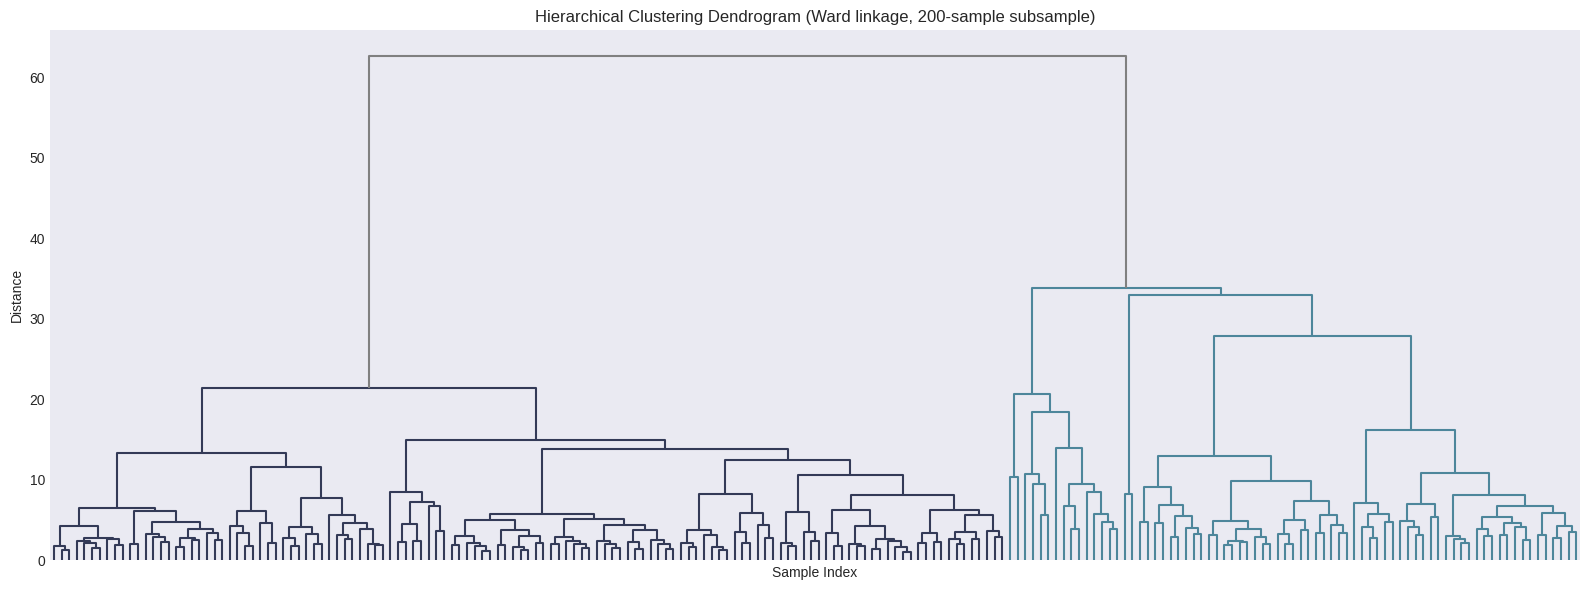

In [ ]:
sub_idx = np.random.choice(len(X_train_scaled), size=200, replace=False)
X_sub   = X_train_scaled[sub_idx]

Z = linkage(X_sub, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=COLORS)

dendrogram(Z, ax=ax, no_labels=True,
           above_threshold_color='grey')

ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage, 200-sample subsample)', fontsize=12)
ax.set_xlabel('Sample Index')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

In [ ]:
hier_representations = {
    'Baseline (30D)': X_train_scaled,
    'PCA 2D':         X_train_pca2,
    't-SNE 2D':       X_train_tsne_best,
}

hier_rows = []
hier_labels_dict = {}

for rep_name, X_rep in hier_representations.items():
    agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
    hard_labels = agg.fit_predict(X_rep)
    sil = silhouette_score(X_rep, hard_labels)

    hier_rows.append({
        'Representation': rep_name,
        'Silhouette':   round(sil, 4),
    })
    hier_labels_dict[rep_name] = hard_labels

hier_df = pd.DataFrame(hier_rows).set_index('Representation')
print('Hierarchical Clustering (Ward, k=2) — Silhouette Scores (internal, label-free):')
display(hier_df)

agg_labels = hier_labels_dict['Baseline (30D)']
sil_agg    = hier_df.loc['Baseline (30D)', 'Silhouette']

Hierarchical Clustering (Ward, k=2) — Silhouette Scores (internal, label-free):


,Silhouette
Representation,
Baseline (30D),0.2886
PCA 2D,0.4821
t-SNE 2D,0.5028


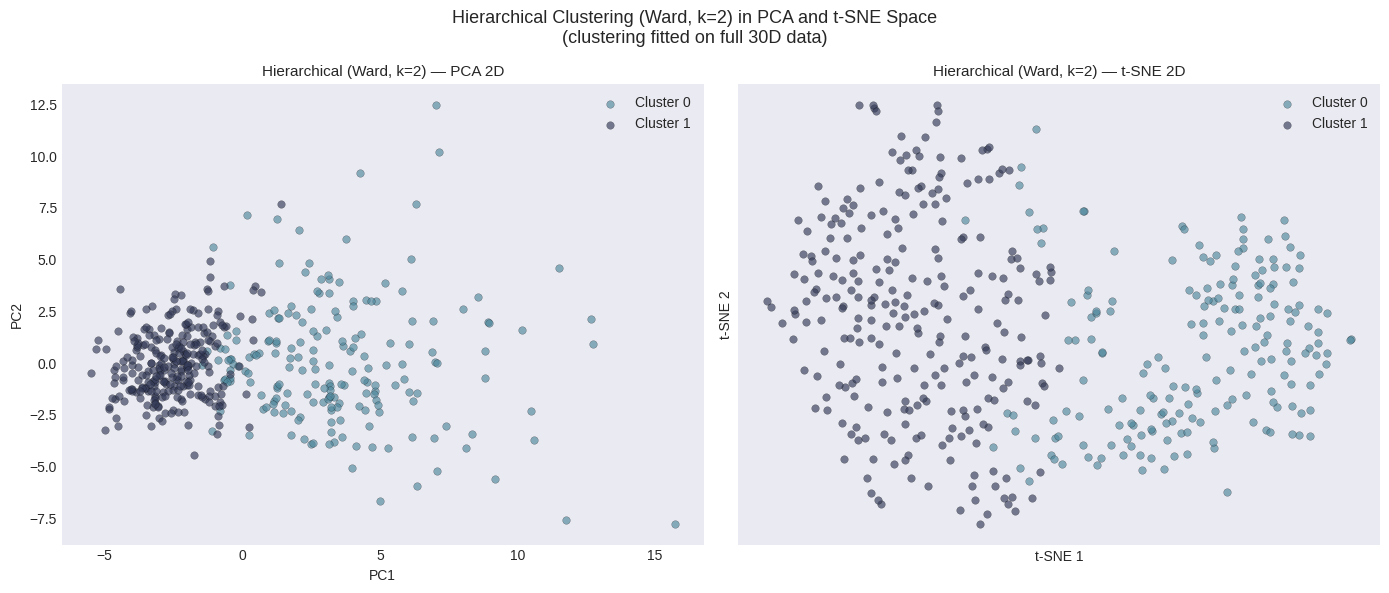

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sil_val = sil_agg

for clust, color in zip([0, 1], COLORS):
    mask = agg_labels == clust
    axes[0].scatter(X_train_pca2[mask, 0], X_train_pca2[mask, 1],
                    label=f'Cluster {clust}', color=color, alpha=0.65,
                    edgecolors='black', linewidths=0.2, s=30)
axes[0].set_title(f'Hierarchical (Ward, k=2) — PCA 2D', fontsize=11)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

for clust, color in zip([0, 1], COLORS):
    mask = agg_labels == clust
    axes[1].scatter(X_train_tsne_best[mask, 0], X_train_tsne_best[mask, 1],
                    label=f'Cluster {clust}', color=color, alpha=0.65,
                    edgecolors='black', linewidths=0.2, s=30)
axes[1].set_title(f'Hierarchical (Ward, k=2) — t-SNE 2D', fontsize=11)
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].set_xticks([]); axes[1].set_yticks([])
axes[1].legend()

plt.suptitle('Hierarchical Clustering (Ward, k=2) in PCA and t-SNE Space\n(clustering fitted on full 30D data)', fontsize=13)
plt.tight_layout()
plt.show()

### 5.4 Unsupervised Summary & Comparison



In [ ]:
rows = []
for method, df in [('K-Means',      km_df),
                   ('GMM',           gmm_df),
                   ('Hierarchical',  hier_df)]:
    for rep_name, row in df.iterrows():
        rows.append({'Method': method,
                     'Representation': rep_name,
                     'Silhouette': row['Silhouette']})


master_df = pd.DataFrame(rows).set_index(['Method', 'Representation'])
print('Master Clustering Comparison — Silhouette Score (label-free):')
display(master_df)

Master Clustering Comparison — Silhouette Score (label-free):


Silhouette
Method       Representation            
K-Means      Baseline (30D)      0.3432
             PCA 2D              0.5092
             t-SNE 2D            0.5521
GMM          Baseline (30D)      0.3142
             PCA 2D              0.4736
             t-SNE 2D            0.5532
Hierarchical Baseline (30D)      0.2886
             PCA 2D              0.4821
             t-SNE 2D            0.5028

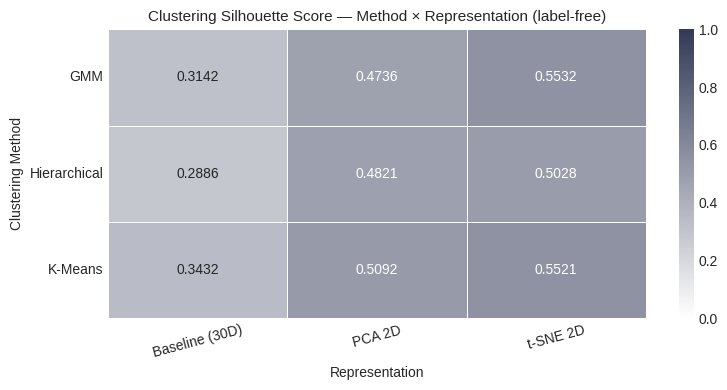

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

pivot = master_df['Silhouette'].unstack('Representation')
col_order = ['Baseline (30D)', 'PCA 2D', 't-SNE 2D']
pivot = pivot[[c for c in col_order if c in pivot.columns]]

cmap_sil = LinearSegmentedColormap.from_list('sil_cmap', ['#FFFFFF', '#333A57'])
sns.heatmap(pivot, ax=ax, annot=True, fmt='.4f', cmap=cmap_sil,
            linewidths=0.5, linecolor='white', vmin=0, vmax=1)
ax.set_title('Clustering Silhouette Score — Method × Representation (label-free)', fontsize=11)
ax.set_xlabel('Representation')
ax.set_ylabel('Clustering Method')
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


### 5.5 Outlook






Outlook — Label-based verification (labels NOT used in fitting):


ARI  Recall      F1
Method       Representation                        
K-Means      Baseline (30D)  0.6622  0.8412  0.8720
             PCA 2D          0.6693  0.8353  0.8738
             t-SNE 2D        0.6921  0.8941  0.8889
GMM          Baseline (30D)  0.7524  0.9294  0.9133
             PCA 2D          0.6419  0.9059  0.8725
             t-SNE 2D        0.7516  0.8706  0.9080
Hierarchical Baseline (30D)  0.6212  0.9235  0.8674
             PCA 2D          0.6206  0.8824  0.8621
             t-SNE 2D        0.4780  0.9059  0.8148

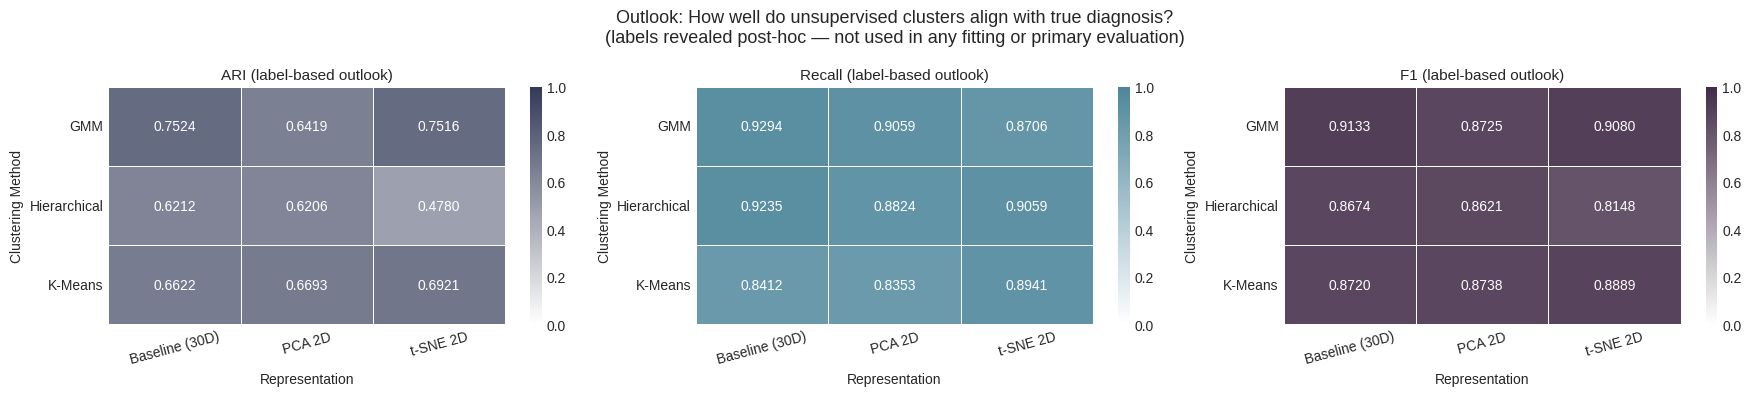

In [ ]:
label_sources = {
    'K-Means':      km_labels_dict,
    'GMM':          gmm_labels_dict,
    'Hierarchical': hier_labels_dict,
}

outlook_rows = []
for method, lbl_dict in label_sources.items():
    for rep_name, lbl in lbl_dict.items():
        aligned = align_clusters(lbl, y_train.values)
        ari_v   = adjusted_rand_score(y_train, lbl)
        rec_v   = recall_score(y_train, aligned, pos_label=1, zero_division=0)
        f1_v    = f1_score(y_train, aligned, pos_label=1, zero_division=0)

        outlook_rows.append({
            'Method':         method,
            'Representation': rep_name,
            'ARI':            round(ari_v, 4),
            'Recall':         round(rec_v, 4),
            'F1':             round(f1_v,  4),
        })

outlook_df = pd.DataFrame(outlook_rows).set_index(['Method', 'Representation'])
print('Outlook — Label-based verification (labels NOT used in fitting):')
display(outlook_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
col_order = ['Baseline (30D)', 'PCA 2D', 't-SNE 2D']
metrics   = ['ARI', 'Recall', 'F1']
cmaps     = [
    LinearSegmentedColormap.from_list('ari',    ['#FFFFFF', '#333A57']),
    LinearSegmentedColormap.from_list('recall', ['#FFFFFF', '#4D869B']),
    LinearSegmentedColormap.from_list('f1',     ['#FFFFFF', '#422C47']),
]

for ax, metric, cmap in zip(axes, metrics, cmaps):
    pivot = outlook_df[metric].unstack('Representation')
    pivot = pivot[[c for c in col_order if c in pivot.columns]]
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.4f', cmap=cmap,
                linewidths=0.5, linecolor='white', vmin=0, vmax=1)
    ax.set_title(f'{metric} (label-based outlook)', fontsize=11)
    ax.set_xlabel('Representation')
    ax.set_ylabel('Clustering Method')
    ax.tick_params(axis='x', rotation=15)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Outlook: How well do unsupervised clusters align with true diagnosis?\n'
             '(labels revealed post-hoc — not used in any fitting or primary evaluation)',
             fontsize=13)
plt.tight_layout()
plt.show()


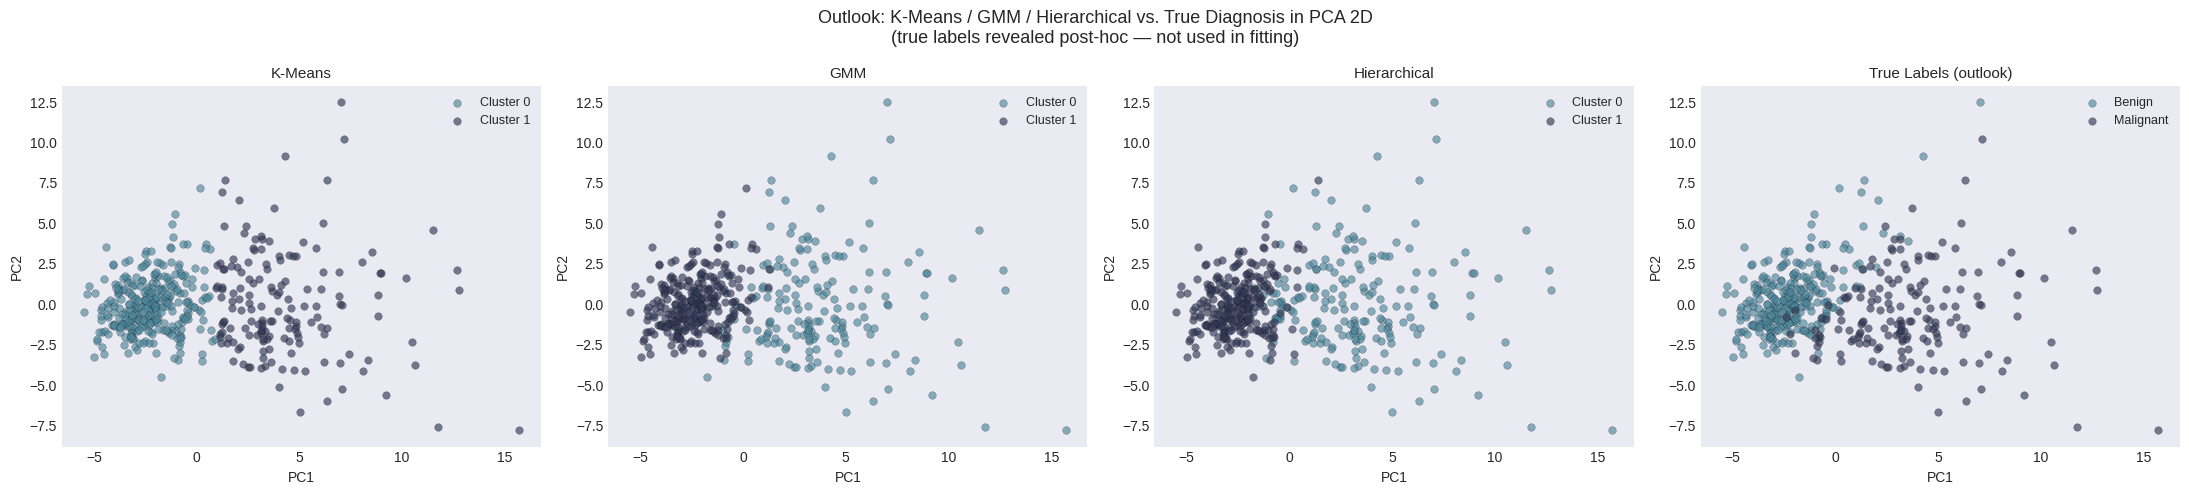

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

method_names  = ['K-Means', 'GMM', 'Hierarchical']
method_labels = [
    km_labels_train,
    gmm_proba_dict['Baseline (30D)'].argmax(axis=1),
    agg_labels,
]

for ax, method_name, lbl in zip(axes[:3], method_names, method_labels):
    for clust, color in zip([0, 1], COLORS):
        mask = lbl == clust
        ax.scatter(X_train_pca2[mask, 0], X_train_pca2[mask, 1],
                   color=color, alpha=0.65, edgecolors='black',
                   linewidths=0.2, s=30, label=f'Cluster {clust}')
    ax.set_title(method_name, fontsize=11)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=9)

for label, name, color in zip([0, 1], ['Benign', 'Malignant'], COLORS):
    mask = y_train == label
    axes[3].scatter(X_train_pca2[mask, 0], X_train_pca2[mask, 1],
                    color=color, alpha=0.65, edgecolors='black',
                    linewidths=0.2, s=30, label=name)
axes[3].set_title('True Labels (outlook)', fontsize=11)
axes[3].set_xlabel('PC1'); axes[3].set_ylabel('PC2')
axes[3].legend(fontsize=9)

plt.suptitle('Outlook: K-Means / GMM / Hierarchical vs. True Diagnosis in PCA 2D\n'
             '(true labels revealed post-hoc — not used in fitting)', fontsize=13)
plt.tight_layout()
plt.show()

## **6. Supervised Learning**

### 6.1 Setup

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te, pos_label=1):
    """Fit, evaluate, and return metrics for a pipeline."""
    pipeline.fit(X_tr, y_tr)
    y_pred_tr = pipeline.predict(X_tr)
    y_pred_te = pipeline.predict(X_te)

    acc_tr  = accuracy_score(y_tr, y_pred_tr)
    acc_te  = accuracy_score(y_te, y_pred_te)
    prec    = precision_score(y_te, y_pred_te, pos_label=pos_label, zero_division=0)
    rec     = recall_score(y_te, y_pred_te, pos_label=pos_label)
    f1      = f1_score(y_te, y_pred_te, pos_label=pos_label)

    if hasattr(pipeline, 'predict_proba'):
        scores = pipeline.predict_proba(X_te)[:, 1]
    else:
        scores = pipeline.decision_function(X_te)
    auc = roc_auc_score(y_te, scores)

    print(f'\n── {name} ──')
    print(f'  Train Accuracy : {acc_tr:.4f}')
    print(f'  Test  Accuracy : {acc_te:.4f}')
    print(f'  Precision      : {prec:.4f}')
    print(f'  Recall         : {rec:.4f}')
    print(f'  F1-Score       : {f1:.4f}')
    print(f'  AUC            : {auc:.4f}')

    cm = confusion_matrix(y_te, y_pred_te)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
    disp.plot(cmap=cm_cmap)
    plt.title(f'{name} — Confusion Matrix')
    plt.show()

    return {
        'Model': name,
        'Train Acc': acc_tr, 'Test Acc': acc_te,
        'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc,
        'pipeline': pipeline, 'y_pred': y_pred_te
    }

results = []

### 6.2 Logistic Regression

Best C (Logistic Regression): 0.033598

── Logistic Regression ──
  Train Accuracy : 0.9780
  Test  Accuracy : 0.9825
  Precision      : 1.0000
  Recall         : 0.9524
  F1-Score       : 0.9756
  AUC            : 0.9980


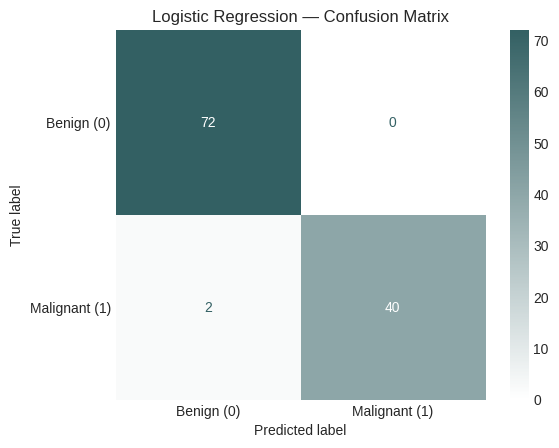

In [ ]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear', max_iter=1000))
])

param_grid_lr = {'classifier__C': np.logspace(-4, 4, 20)}

gs_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=skf, scoring='recall', n_jobs=-1)
gs_lr.fit(X_train, y_train)
best_lr = gs_lr.best_estimator_

print(f'Best C (Logistic Regression): {gs_lr.best_params_["classifier__C"]:.6f}')
res_lr = evaluate_model('Logistic Regression', best_lr, X_train, y_train, X_test, y_test)
results.append({k: v for k, v in res_lr.items() if k not in ['pipeline', 'y_pred']})

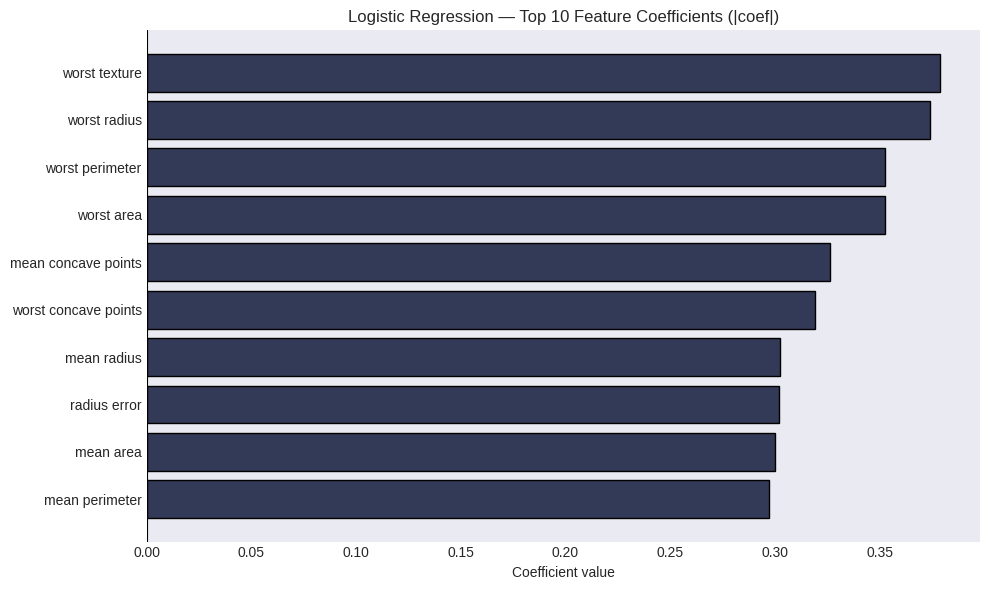

In [ ]:
lr_coef = pd.Series(
    best_lr.named_steps['classifier'].coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top10 = lr_coef.head(10)
colors_coef = [C_MALIGNANT if v > 0 else C_BENIGN for v in top10.values]
ax.barh(top10.index[::-1], top10.values[::-1], color=colors_coef[::-1], edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Top 10 Feature Coefficients (|coef|)', fontsize=12)
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

### 6.3 Linear SVM

Best C (Linear SVM): 29.763514

── Linear SVM ──
  Train Accuracy : 0.9956
  Test  Accuracy : 0.9386
  Precision      : 0.9487
  Recall         : 0.8810
  F1-Score       : 0.9136
  AUC            : 0.9679


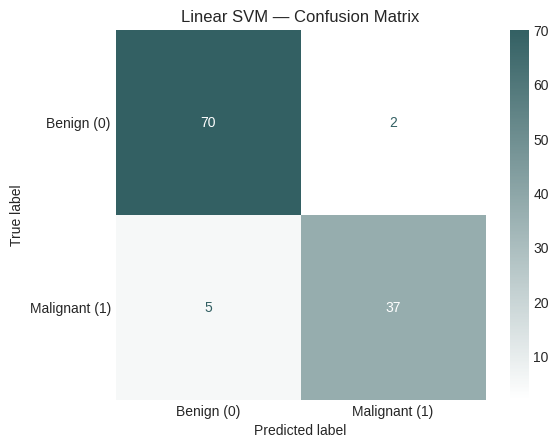

In [ ]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LinearSVC(random_state=42, dual=False, max_iter=5000))
])

param_grid_svm = {'classifier__C': np.logspace(-4, 4, 20)}

gs_svm = GridSearchCV(svm_pipeline, param_grid_svm, cv=skf, scoring='recall', n_jobs=-1)
gs_svm.fit(X_train, y_train)
best_svm = gs_svm.best_estimator_

print(f'Best C (Linear SVM): {gs_svm.best_params_["classifier__C"]:.6f}')
res_svm = evaluate_model('Linear SVM', best_svm, X_train, y_train, X_test, y_test)
results.append({k: v for k, v in res_svm.items() if k not in ['pipeline', 'y_pred']})

### 6.4 k-Nearest Neighbors

kNN (k=1) Training Accuracy: 1.0000 — perfect fit = overfitting
Best k (kNN): 3

── kNN (best k) ──
  Train Accuracy : 0.9846
  Test  Accuracy : 0.9386
  Precision      : 0.9730
  Recall         : 0.8571
  F1-Score       : 0.9114
  AUC            : 0.9825


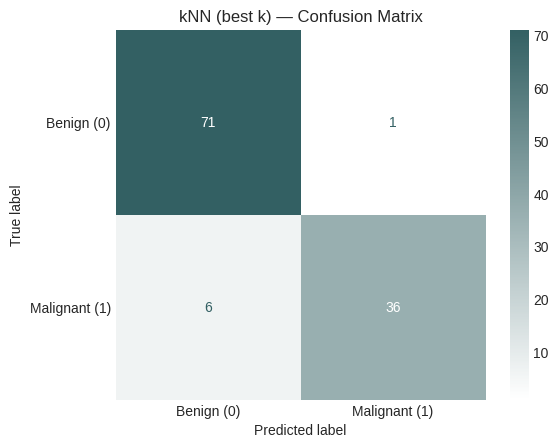

In [ ]:
knn_k1 = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=1))
])
knn_k1.fit(X_train, y_train)
acc_k1_train = accuracy_score(y_train, knn_k1.predict(X_train))
print(f'kNN (k=1) Training Accuracy: {acc_k1_train:.4f} — perfect fit = overfitting')

max_k = int(math.sqrt(len(X_train))) | 1
k_vals = list(range(1, max_k + 2, 2))

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])
param_grid_knn = {'classifier__n_neighbors': k_vals}

gs_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=skf, scoring='recall', n_jobs=-1)
gs_knn.fit(X_train, y_train)
best_knn = gs_knn.best_estimator_

print(f'Best k (kNN): {gs_knn.best_params_["classifier__n_neighbors"]}')
res_knn = evaluate_model('kNN (best k)', best_knn, X_train, y_train, X_test, y_test)
results.append({k: v for k, v in res_knn.items() if k not in ['pipeline', 'y_pred']})

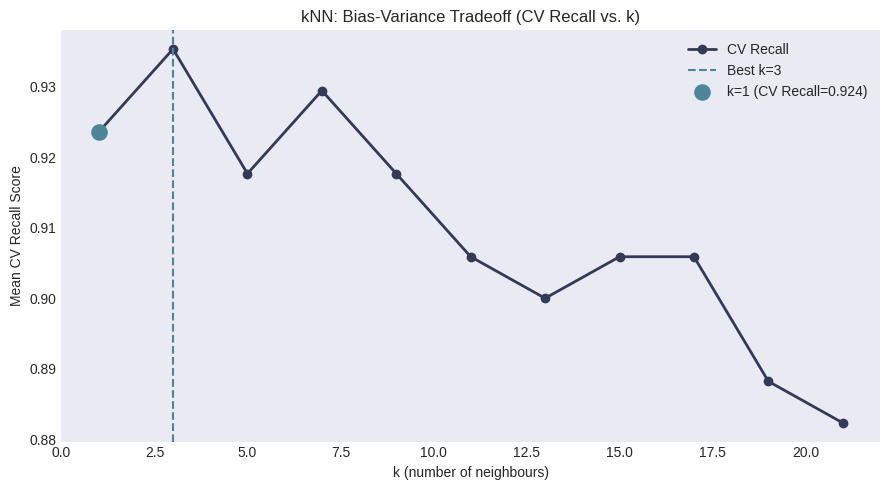

In [ ]:
cv_recall_vals = []
for k in k_vals:
    pipe_k = Pipeline([('scaler', StandardScaler()),
                       ('classifier', KNeighborsClassifier(n_neighbors=k))])
    scores = cross_val_score(pipe_k, X_train, y_train, cv=skf, scoring='recall')
    cv_recall_vals.append(scores.mean())

best_k = gs_knn.best_params_['classifier__n_neighbors']

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_vals, cv_recall_vals, marker='o', color=C_MALIGNANT, linewidth=2, label='CV Recall')
ax.axvline(best_k, color=C_BENIGN, linestyle='--', label=f'Best k={best_k}')
scores_k1 = cross_val_score(knn_k1, X_train, y_train, cv=skf, scoring='recall')
ax.scatter([1], [scores_k1.mean()], color=C_BENIGN, s=120, zorder=5, label=f'k=1 (CV Recall={scores_k1.mean():.3f})')
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel('Mean CV Recall Score')
ax.set_title('kNN: Bias-Variance Tradeoff (CV Recall vs. k)')
ax.legend()
plt.tight_layout()
plt.show()

### 6.5 Random Forest

Best RF params: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

── Random Forest ──
  Train Accuracy : 1.0000
  Test  Accuracy : 0.9737
  Precision      : 1.0000
  Recall         : 0.9286
  F1-Score       : 0.9630
  AUC            : 0.9929


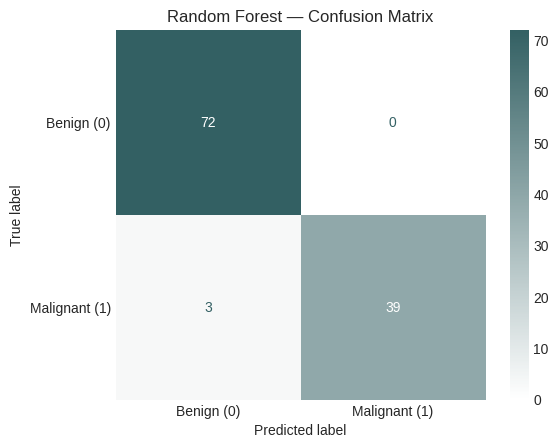

In [ ]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

gs_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=skf, scoring='recall', n_jobs=-1)
gs_rf.fit(X_train, y_train)
best_rf = gs_rf.best_estimator_

print('Best RF params:', gs_rf.best_params_)
res_rf = evaluate_model('Random Forest', best_rf, X_train, y_train, X_test, y_test)
results.append({k: v for k, v in res_rf.items() if k not in ['pipeline', 'y_pred']})


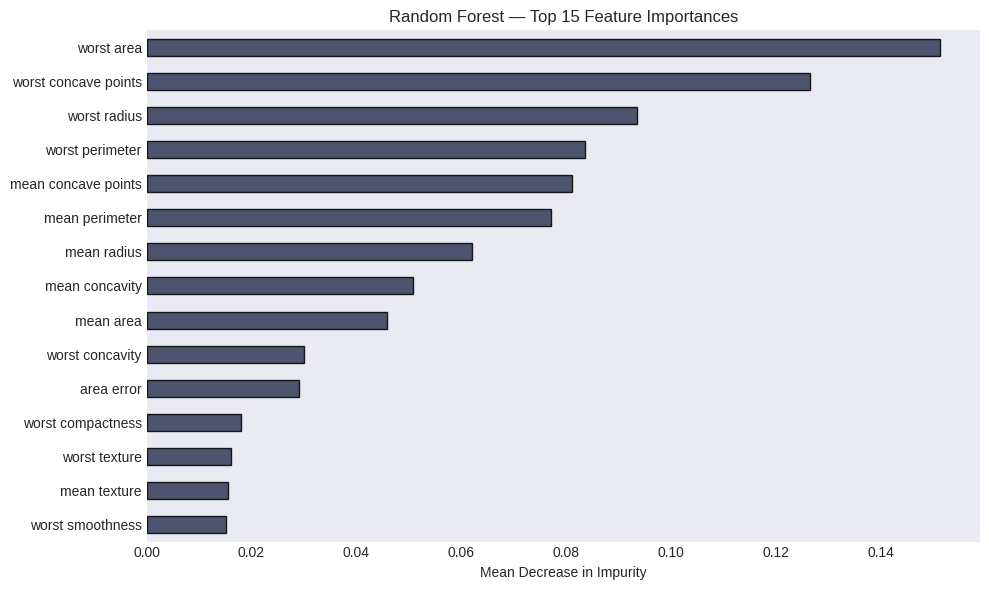

In [ ]:
rf_importances = pd.Series(
    best_rf.named_steps['classifier'].feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
rf_importances.head(15).sort_values().plot(
    kind='barh', ax=ax, color=C_MALIGNANT, edgecolor='black', alpha=0.85
)
ax.set_title('Random Forest — Top 15 Feature Importances')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

### 6.6 Cost-Sensitive Improvement

Best C (LR cost-sensitive): 0.233572

── Logistic Regression (balanced) ──
  Train Accuracy : 0.9824
  Test  Accuracy : 0.9825
  Precision      : 0.9762
  Recall         : 0.9762
  F1-Score       : 0.9762
  AUC            : 0.9977


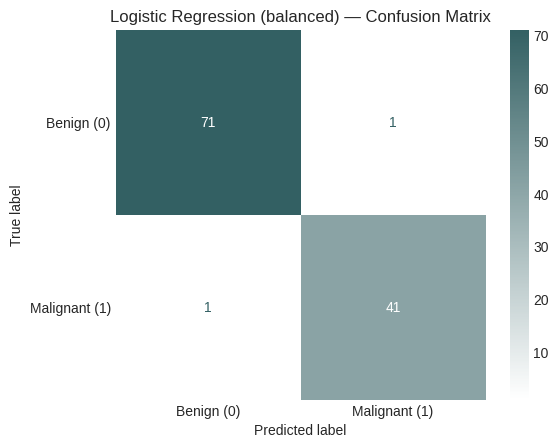

In [ ]:
lr_cs_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        random_state=42, solver='liblinear', max_iter=1000,
        class_weight='balanced'
    ))
])

gs_lr_cs = GridSearchCV(lr_cs_pipeline, param_grid_lr, cv=skf, scoring='recall', n_jobs=-1)
gs_lr_cs.fit(X_train, y_train)
best_lr_cs = gs_lr_cs.best_estimator_

print(f'Best C (LR cost-sensitive): {gs_lr_cs.best_params_["classifier__C"]:.6f}')
res_lr_cs = evaluate_model('Logistic Regression (balanced)', best_lr_cs, X_train, y_train, X_test, y_test)
results.append({k: v for k, v in res_lr_cs.items() if k not in ['pipeline', 'y_pred']})

Best C (SVM cost-sensitive): 0.001833

── Linear SVM (balanced) ──
  Train Accuracy : 0.9802
  Test  Accuracy : 0.9912
  Precision      : 1.0000
  Recall         : 0.9762
  F1-Score       : 0.9880
  AUC            : 0.9983


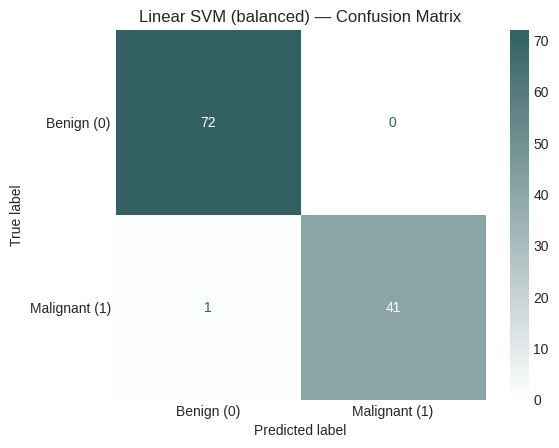

In [ ]:
svm_cs_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LinearSVC(
        random_state=42, dual=False, max_iter=5000,
        class_weight='balanced'
    ))
])

gs_svm_cs = GridSearchCV(svm_cs_pipeline, param_grid_svm, cv=skf, scoring='recall', n_jobs=-1)
gs_svm_cs.fit(X_train, y_train)
best_svm_cs = gs_svm_cs.best_estimator_

print(f'Best C (SVM cost-sensitive): {gs_svm_cs.best_params_["classifier__C"]:.6f}')
res_svm_cs = evaluate_model('Linear SVM (balanced)', best_svm_cs, X_train, y_train, X_test, y_test)
results.append({k: v for k, v in res_svm_cs.items() if k not in ['pipeline', 'y_pred']})

Best RF (cost-sensitive) params: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

── Random Forest (balanced) ──
  Train Accuracy : 1.0000
  Test  Accuracy : 0.9737
  Precision      : 1.0000
  Recall         : 0.9286
  F1-Score       : 0.9630
  AUC            : 0.9965


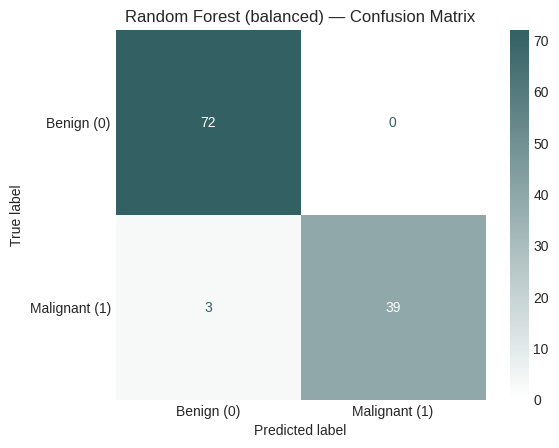

In [ ]:
rf_cs_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'))
])

param_grid_rf_cs = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

gs_rf_cs = GridSearchCV(rf_cs_pipeline, param_grid_rf_cs, cv=skf, scoring='recall', n_jobs=-1)
gs_rf_cs.fit(X_train, y_train)
best_rf_cs = gs_rf_cs.best_estimator_

print('Best RF (cost-sensitive) params:', gs_rf_cs.best_params_)
res_rf_cs = evaluate_model('Random Forest (balanced)', best_rf_cs, X_train, y_train, X_test, y_test)
results.append({k: v for k, v in res_rf_cs.items() if k not in ['pipeline', 'y_pred']})

### 6.7 Supervised Summary

In [ ]:
results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df = results_df[~results_df.index.duplicated(keep='last')]
print('\nFull Model Performance Comparison:')
display(results_df)


Full Model Performance Comparison:


,Train Acc,Test Acc,Precision,Recall,F1,AUC
Model,,,,,,
Logistic Regression,0.9780,0.9825,1.0000,0.9524,0.9756,0.9980
Linear SVM,0.9956,0.9386,0.9487,0.8810,0.9136,0.9679
kNN (best k),0.9846,0.9386,0.9730,0.8571,0.9114,0.9825
Random Forest,1.0000,0.9737,1.0000,0.9286,0.9630,0.9929
Logistic Regression (balanced),0.9824,0.9825,0.9762,0.9762,0.9762,0.9977
Linear SVM (balanced),0.9802,0.9912,1.0000,0.9762,0.9880,0.9983
Random Forest (balanced),1.0000,0.9737,1.0000,0.9286,0.9630,0.9965


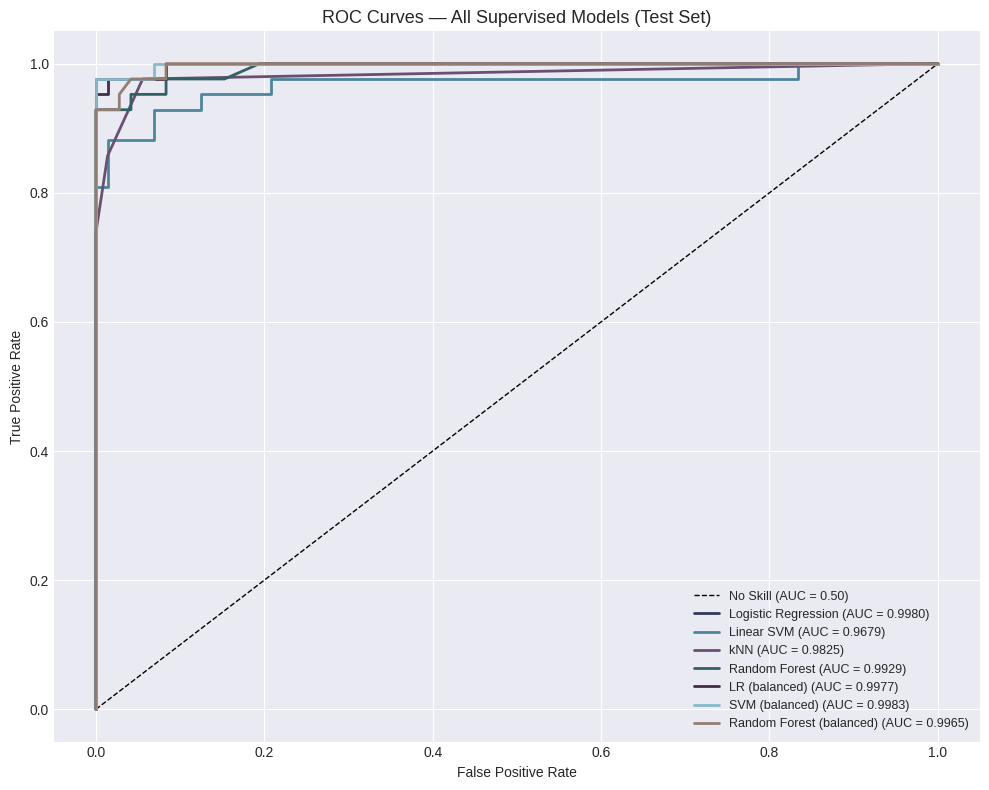

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], 'k--', label='No Skill (AUC = 0.50)', linewidth=1)

model_plot_list = [
    (best_lr,       'Logistic Regression',  C_MALIGNANT),
    (best_svm,      'Linear SVM',           C_BENIGN),
    (best_knn,      'kNN',                  '#6B4F72'),
    (best_rf,       'Random Forest',        '#336063'),
    (best_lr_cs,    'LR (balanced)',        '#422C47'),
    (best_svm_cs,   'SVM (balanced)',       '#88BAC8'),
    (best_rf_cs,    'Random Forest (balanced)', '#927D72'),
]

for pipe, name, color in model_plot_list:
    if hasattr(pipe, 'predict_proba'):
        scores = pipe.predict_proba(X_test)[:, 1]
    else:
        scores = pipe.decision_function(X_test)
    auc_val = roc_auc_score(y_test, scores)
    fpr, tpr, _ = roc_curve(y_test, scores)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {auc_val:.4f})')

ax.set_title('ROC Curves — All Supervised Models (Test Set)', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

## **7. Connection Between the Two Parts**


### 7.1 Does PCA Help Prediction?

In [ ]:
n_components_list = sorted(set([2, 5, 10, n_90])) + [30]
pca_comparison = []

for n in n_components_list:
    if n == 30:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(random_state=42, solver='liblinear',
                                              C=gs_lr_cs.best_params_['classifier__C'], class_weight='balanced'))
        ])
        label = 'Raw (30 features)'
    else:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=n, random_state=42)),
            ('classifier', LogisticRegression(random_state=42, solver='liblinear',
                                              C=gs_lr_cs.best_params_['classifier__C'], class_weight='balanced'))
        ])
        label = f'PCA ({n} components)'

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    f1_val = f1_score(y_test, y_pred)
    recall_val = recall_score(y_test, y_pred)

    pca_comparison.append({'Features': label, 'F1': f1_val, 'Recall': recall_val})

pca_df = pd.DataFrame(pca_comparison).set_index('Features').round(4)
print('Logistic Regression (balanced): Raw Features vs. PCA Components')
display(pca_df)

print()
print(f'Note: PCA fitted on training data only (no leakage).')
print(f'Capturing 90% variance requires {n_90} components.')

print('\n--- Top Features for each of the first 10 Principal Components ---')

for i in range(min(10, pca_full.n_components_)):
    pc_loadings = pd.Series(pca_full.components_[i], index=X.columns)
    top_features = pc_loadings.abs().sort_values(ascending=False).head(5).index.tolist()
    print(f'PC {i+1}: {top_features}')

Logistic Regression (balanced): Raw Features vs. PCA Components


,F1,Recall
Features,,
PCA (2 components),0.9762,0.9762
PCA (5 components),0.9639,0.9524
PCA (7 components),0.9524,0.9524
PCA (10 components),0.9639,0.9524
Raw (30 features),0.9762,0.9762



Note: PCA fitted on training data only (no leakage).
Capturing 90% variance requires 7 components.

--- Top Features for each of the first 10 Principal Components ---
PC 1: ['mean concave points', 'mean concavity', 'worst concave points', 'mean compactness', 'worst perimeter']
PC 2: ['mean fractal dimension', 'worst fractal dimension', 'fractal dimension error', 'mean radius', 'mean area']
PC 3: ['texture error', 'smoothness error', 'symmetry error', 'worst smoothness', 'radius error']
PC 4: ['worst texture', 'mean texture', 'texture error', 'mean smoothness', 'area error']
PC 5: ['mean smoothness', 'concavity error', 'worst smoothness', 'mean symmetry', 'compactness error']
PC 6: ['worst symmetry', 'symmetry error', 'mean symmetry', 'smoothness error', 'worst smoothness']
PC 7: ['worst fractal dimension', 'concave points error', 'smoothness error', 'area error', 'perimeter error']
PC 8: ['texture error', 'smoothness error', 'mean smoothness', 'worst symmetry', 'mean texture']
PC 9: [

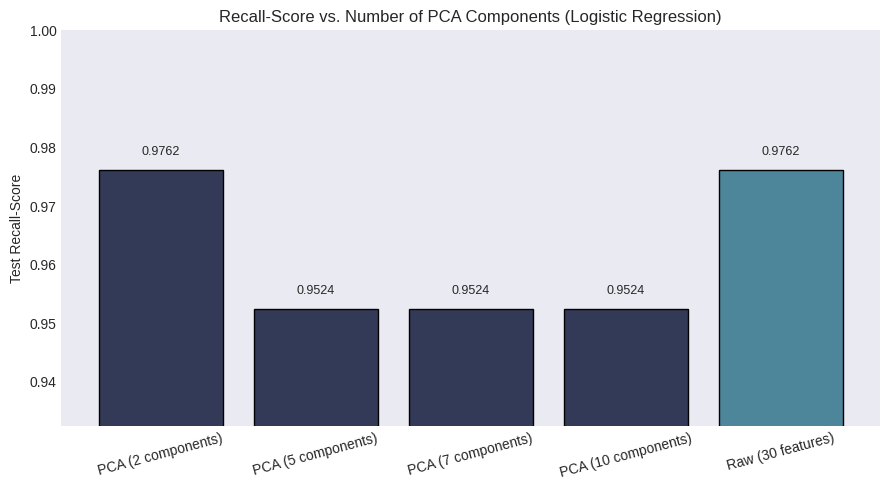

In [ ]:
labels_plot = pca_df.index.tolist()
recall_vals_plot = pca_df['Recall'].values
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [C_MALIGNANT] * (len(labels_plot) - 1) + [C_BENIGN]
bars = ax.bar(labels_plot, recall_vals_plot, color=bar_colors, edgecolor='black')
for bar, val in zip(bars, recall_vals_plot):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(min(recall_vals_plot) - 0.02, 1.0)
ax.set_title('Recall-Score vs. Number of PCA Components (Logistic Regression)')
ax.set_ylabel('Test Recall-Score')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### 7.2 Do Clusters Correspond to True Labels?

Results are drawn from the label-based verification in Section 5.5 and discussed in the report.


### 7.3 Does Cluster Membership Improve Prediction?

In [ ]:
km_test_labels = km_train.predict(X_test_scaled)

_cluster_scaler = StandardScaler()
km_train_col = _cluster_scaler.fit_transform(km_train_labels.reshape(-1, 1))
km_test_col  = _cluster_scaler.transform(km_test_labels.reshape(-1, 1))

X_train_aug = np.column_stack([X_train_scaled, km_train_col])
X_test_aug  = np.column_stack([X_test_scaled,  km_test_col])

lr_aug = LogisticRegression(random_state=42, solver='liblinear',
            C=gs_lr_cs.best_params_['classifier__C'], class_weight='balanced')
lr_aug.fit(X_train_aug, y_train)

y_pred_aug = lr_aug.predict(X_test_aug)
f1_aug     = f1_score(y_test, y_pred_aug)
recall_aug = recall_score(y_test, y_pred_aug)

f1_base    = res_lr_cs['F1']
recall_base = res_lr_cs['Recall']

print('Logistic Regression (balanced): with vs. without cluster feature:')
print(f'  Without cluster — F1: {f1_base:.4f} | Recall: {recall_base:.4f}')
print(f'  With    cluster — F1: {f1_aug:.4f}  | Recall: {recall_aug:.4f}')

Logistic Regression (balanced): with vs. without cluster feature:
  Without cluster — F1: 0.9762 | Recall: 0.9762
  With    cluster — F1: 0.9639  | Recall: 0.9524


### 7.4 Do Unsupervised Methods Explain Model Errors?

Total test errors: 2 out of 114
Error rate: 1.75%


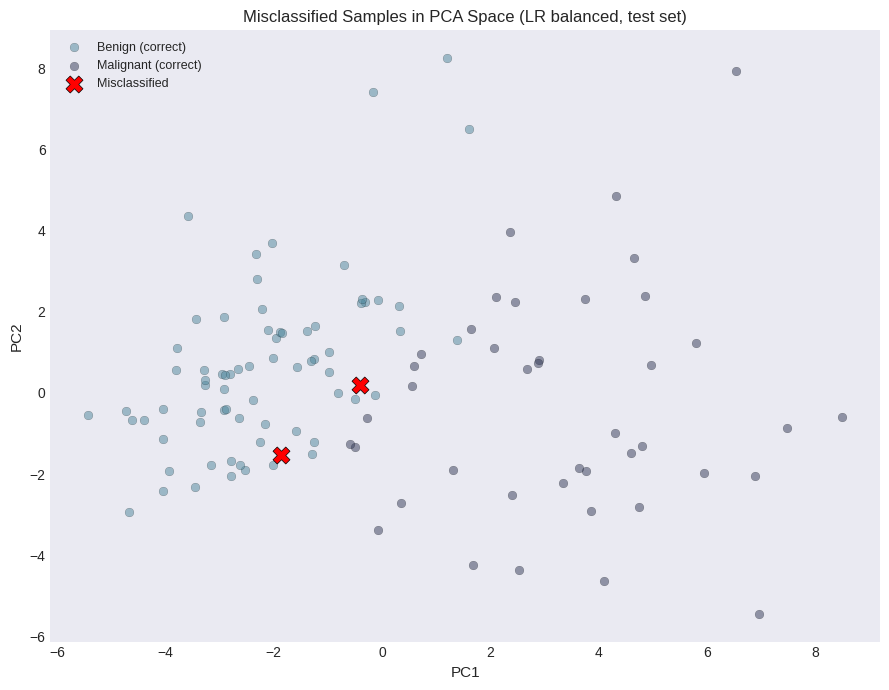

In [ ]:
y_pred_best = best_lr_cs.predict(X_test)
errors_mask  = (y_pred_best != y_test.values)

print(f'Total test errors: {errors_mask.sum()} out of {len(y_test)}')
print(f'Error rate: {errors_mask.mean():.2%}')

X_test_pca2 = pca_2d.transform(X_test_scaled)

fig, ax = plt.subplots(figsize=(9, 7))

for label, name, color in zip([0, 1], ['Benign (correct)', 'Malignant (correct)'], COLORS):
    mask = (~errors_mask) & (y_test.values == label)
    ax.scatter(X_test_pca2[mask, 0], X_test_pca2[mask, 1],
               label=name, color=color, alpha=0.5, edgecolors='black', linewidths=0.2, s=40)

ax.scatter(X_test_pca2[errors_mask, 0], X_test_pca2[errors_mask, 1],
           label='Misclassified', color='red', marker='X', s=150,
           edgecolors='black', linewidths=0.5, zorder=5)

ax.set_xlabel('PC1', fontsize=11); ax.set_ylabel('PC2', fontsize=11)
ax.set_title('Misclassified Samples in PCA Space (LR balanced, test set)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Total test errors (GMM): 11 out of 114
Error rate (GMM): 9.65%


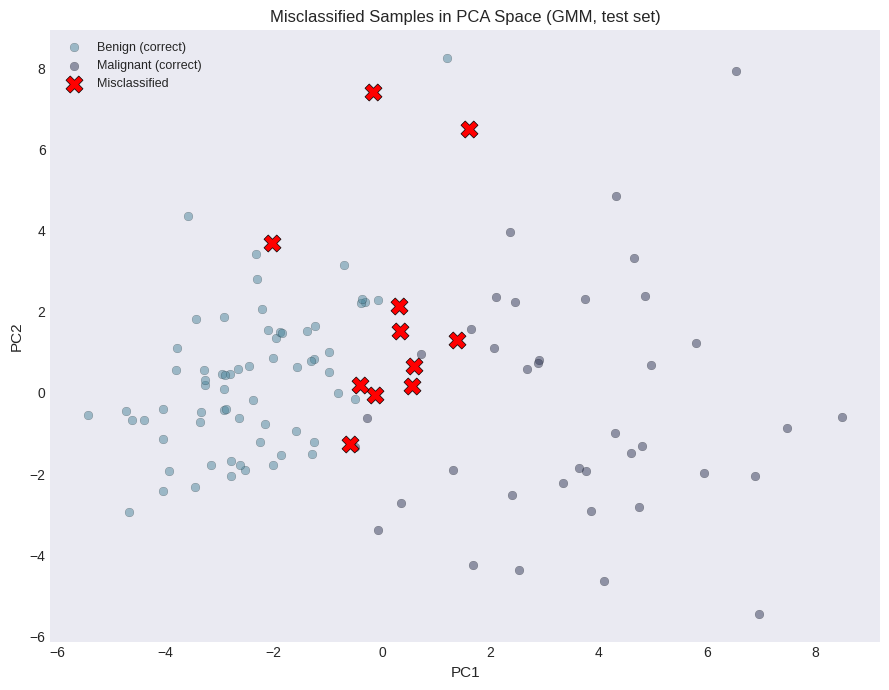

In [ ]:
gmm_train = GaussianMixture(n_components=2, covariance_type='full',
                          random_state=42, max_iter=200)
gmm_train.fit(X_train_scaled)
gmm_train_pred_raw = gmm_train.predict(X_train_scaled)
gmm_pred_raw = gmm_train.predict(X_test_scaled)

mapping = {}
for c in np.unique(gmm_train_pred_raw):
    true_in_c = y_train.values[gmm_train_pred_raw == c]
    if len(true_in_c) > 0:
        aligned_label = mode(true_in_c, keepdims=True).mode[0]
        mapping[c] = aligned_label

y_pred_gmm = np.array([mapping.get(c, -1) for c in gmm_pred_raw])

errors_mask_gmm  = (y_pred_gmm != y_test.values)

print(f'Total test errors (GMM): {errors_mask_gmm.sum()} out of {len(y_test)}')
print(f'Error rate (GMM): {errors_mask_gmm.mean():.2%}')

X_test_pca2 = pca_2d.transform(X_test_scaled)

fig, ax = plt.subplots(figsize=(9, 7))

for label, name, color in zip([0, 1], ['Benign (correct)', 'Malignant (correct)'], COLORS):
    mask = (~errors_mask_gmm) & (y_test.values == label)
    ax.scatter(X_test_pca2[mask, 0], X_test_pca2[mask, 1],
               label=name, color=color, alpha=0.5, edgecolors='black', linewidths=0.2, s=40)

ax.scatter(X_test_pca2[errors_mask_gmm, 0], X_test_pca2[errors_mask_gmm, 1],
           label='Misclassified', color='red', marker='X', s=150,
           edgecolors='black', linewidths=0.5, zorder=5)

ax.set_xlabel('PC1', fontsize=11); ax.set_ylabel('PC2', fontsize=11)
ax.set_title('Misclassified Samples in PCA Space (GMM, test set)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()